# Problem 2 — Hardware-Aware Circuit Design for Long-Range CNOT Gate Teleportation

**2026 Quantum Hackathon — Dynamic Circuits (지정문제 4)**

Reference: Bäumer *et al.*, [Efficient Long-Range Entanglement Using Dynamic Circuits](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.030339), PRX Quantum **5**, 030339 (2024).

This notebook follows the structure of IBM's [long-range-entanglement](https://quantum.cloud.ibm.com/docs/tutorials/long-range-entanglement) tutorial and addresses:

* **2.1** Two topologies (2D square grid & IBM heavy-hex): ancilla-bus qubit assignment
* **2.2** Unitary vs dynamic long-range CNOT; report gate count, depth, mid-circuit measurements


## Learning outcomes

* Build a **dynamic long-range CNOT (LRCX)** via Bell-pair preparation, Bell-basis measurement, and feed-forward (gate teleportation).
* Build a **unitary SWAP-chain** baseline (Appendix B style) and compare with default transpiler output.
* Map logical system + ancilla-bus qubits onto **square** and **heavy-hex** hardware topologies.
* Profile **two-qubit depth**, **CX/ECR count**, and **mid-circuit measurement** count vs separation `n`.


## Setup


In [25]:
from __future__ import annotations

import math
from collections import deque
from dataclasses import dataclass
from statistics import median

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import IfElseOp, Reset
from qiskit.circuit.classical import expr
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap, Layout, generate_preset_pass_manager
from qiskit.visualization import plot_circuit_layout
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, thermal_relaxation_error
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeBrisbane, FakeMiami

SHOTS = 4096
DISTANCE_DEMO = 6

SEED = 1557
random.seed(SEED)
np.random.seed(SEED)

In [26]:
import sys
from importlib.metadata import PackageNotFoundError, version


def pkg_version(distribution_name: str, import_name: str | None = None) -> str:
    """Return installed package version (pip name + optional import name)."""
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        if import_name is None:
            return "not installed"
        try:
            module = __import__(import_name)
            return getattr(module, "__version__", "not installed")
        except Exception:
            return "not installed"


VERSION_ROWS = [
    ("Python", sys.version.split()[0]),
    ("numpy", pkg_version("numpy")),
    ("pandas", pkg_version("pandas")),
    ("matplotlib", pkg_version("matplotlib")),
    ("qiskit", pkg_version("qiskit")),
    ("qiskit-aer", pkg_version("qiskit-aer", "qiskit_aer")),
    ("qiskit-ibm-runtime", pkg_version("qiskit-ibm-runtime", "qiskit_ibm_runtime")),
]

print("Environment versions")
print("-" * 40)
for name, ver in VERSION_ROWS:
    print(f"{name:22s} {ver}")

Environment versions
----------------------------------------
Python                 3.11.9
numpy                  2.4.6
pandas                 3.0.3
matplotlib             3.10.9
qiskit                 2.4.1
qiskit-aer             0.17.2
qiskit-ibm-runtime     0.47.0


### Noise setup note

The active backend/noise setup is defined in the next two code cells:
- `HardwareNoiseOverrides` / `make_custom_backend` helpers (from `custom_backend.ipynb`)
- `backend_miami`, `backend_yonsei`, `backend_miami_sim`, `backend_yonsei_sim` with `MIAMI_OVERRIDES` / `YONSEI_OVERRIDES`


In [27]:
@dataclass(frozen=True)
class HardwareNoiseOverrides:
    """Controls how the reference backend's hardware noise is modified."""

    t1_scale: float = 1.0
    t2_scale: float = 1.0
    t1_us: float | None = None
    t2_us: float | None = None
    gate_error_scale: float = 1.0
    readout_error_scale: float = 1.0
    reset_error_rate: float = 0.01
    include_thermal_relaxation: bool = True
    include_gate_depolarizing: bool = True
    include_readout_error: bool = True


NOISY_GATE_NAMES = {"id", "sx", "x", "cx", "cz", "ecr", "u", "u1", "u2", "u3", "reset"}


def _clip_probability(value: float, upper: float = 1.0) -> float:
    return min(max(float(value), 0.0), upper)


def _qubit_t1_t2_seconds(reference_backend, qubit: int, overrides: HardwareNoiseOverrides) -> tuple[float, float]:
    qubit_properties = reference_backend.target.qubit_properties
    base_t1 = qubit_properties[qubit].t1
    base_t2 = qubit_properties[qubit].t2

    if base_t1 is None or base_t2 is None:
        raise ValueError(f"Qubit {qubit} does not have T1/T2 calibration data.")

    t1 = overrides.t1_us * 1e-6 if overrides.t1_us is not None else base_t1 * overrides.t1_scale
    t2 = overrides.t2_us * 1e-6 if overrides.t2_us is not None else base_t2 * overrides.t2_scale

    if t1 <= 0 or t2 <= 0:
        raise ValueError("T1 and T2 must be positive.")

    t2 = min(t2, 2 * t1)
    return t1, t2


def _thermal_error_for_qubits(reference_backend, qargs: tuple[int, ...], duration_s: float, overrides: HardwareNoiseOverrides):
    if not qargs:
        return None

    errors = []
    for qubit in qargs:
        t1, t2 = _qubit_t1_t2_seconds(reference_backend, qubit, overrides)
        errors.append(thermal_relaxation_error(t1, t2, duration_s))

    combined = errors[0]
    for error in errors[1:]:
        combined = combined.tensor(error)
    return combined


def build_custom_noise_model(reference_backend, overrides: HardwareNoiseOverrides) -> NoiseModel:
    """Build a robust custom noise model; skip invalid channels safely."""
    noise_model = NoiseModel()
    target = reference_backend.target

    for instruction_name in sorted(target.operation_names):
        if instruction_name not in NOISY_GATE_NAMES:
            continue

        for qargs, properties in target[instruction_name].items():
            if qargs is None or properties is None or len(qargs) == 0:
                continue

            duration_s = properties.duration or 0.0
            gate_error = properties.error or 0.0
            channels = []

            if instruction_name == "reset":
                try:
                    channels.append(depolarizing_error(overrides.reset_error_rate, 1))
                except Exception:
                    pass

            if overrides.include_thermal_relaxation and duration_s > 0:
                try:
                    thermal = _thermal_error_for_qubits(reference_backend, qargs, duration_s, overrides)
                    if thermal is not None:
                        channels.append(thermal)
                except Exception:
                    pass

            if overrides.include_gate_depolarizing and gate_error > 0:
                try:
                    num_qubits = len(qargs)
                    max_depol = (4**num_qubits) / (4**num_qubits - 1)
                    depol_probability = _clip_probability(gate_error * overrides.gate_error_scale, max_depol)
                    if depol_probability > 0:
                        channels.append(depolarizing_error(depol_probability, num_qubits))
                except Exception:
                    pass

            if not channels:
                continue

            try:
                combined_error = channels[0]
                for channel in channels[1:]:
                    combined_error = combined_error.compose(channel)
                noise_model.add_quantum_error(combined_error, [instruction_name], list(qargs), warnings=False)
            except Exception:
                # Some composed channels can be ill-defined for specific calibrated entries.
                continue

    if overrides.include_readout_error and "measure" in target.operation_names:
        for qargs, properties in target["measure"].items():
            if qargs is None or len(qargs) != 1 or properties is None or properties.error is None:
                continue
            readout_p = _clip_probability(properties.error * overrides.readout_error_scale, 1.0)
            ro_err = ReadoutError([[1 - readout_p, readout_p], [readout_p, 1 - readout_p]])
            noise_model.add_readout_error(ro_err, [qargs[0]])

    return noise_model


def make_custom_backend(reference_backend, overrides: HardwareNoiseOverrides) -> AerSimulator:
    noise_model = build_custom_noise_model(reference_backend, overrides)
    simulator = AerSimulator.from_backend(reference_backend)
    simulator.set_options(noise_model=noise_model)
    return simulator


def summarize_backend_t1_t2(reference_backend, qubits: list[int] | None = None) -> dict[str, float]:
    qubit_properties = reference_backend.target.qubit_properties
    qubits = qubits or list(range(len(qubit_properties)))
    t1_values = [qubit_properties[q].t1 * 1e6 for q in qubits if qubit_properties[q].t1 is not None]
    t2_values = [qubit_properties[q].t2 * 1e6 for q in qubits if qubit_properties[q].t2 is not None]
    return {
        "num_qubits": len(qubits),
        "median_t1_us": median(t1_values),
        "median_t2_us": median(t2_values),
        "min_t1_us": min(t1_values),
        "min_t2_us": min(t2_values),
    }


In [28]:
# ------------------------- Fake reference backends + custom noise -------------------------
# Topology snapshots:
#   ibm_miami  -> FakeMiami (2D square)
#   ibm_yonsei -> FakeBrisbane (127-qubit Eagle heavy-hex proxy)
# Noise model: custom_backend.ipynb helpers (T1/T2, gate, readout overrides)

backend_miami = FakeMiami()
backend_yonsei = FakeBrisbane()

for _backend in (backend_miami, backend_yonsei):
    if "if_else" not in _backend.target.operation_names:
        _backend.target.add_instruction(IfElseOp, name="if_else")
    if "reset" not in _backend.target.operation_names:
        _backend.target.add_instruction(Reset, name="reset")

# Tune hardware noise here (scales multiply reference fake-backend calibration).
MIAMI_OVERRIDES = HardwareNoiseOverrides(
    t1_scale=0.5,
    t2_scale=0.5,
    gate_error_scale=1.0,
    readout_error_scale=1.5,
    reset_error_rate=0.01,
)
YONSEI_OVERRIDES = HardwareNoiseOverrides(
    t1_scale=0.5,
    t2_scale=0.5,
    gate_error_scale=1.0,
    readout_error_scale=1.5,
    reset_error_rate=0.01,
)

backend_miami_sim = make_custom_backend(backend_miami, MIAMI_OVERRIDES)
backend_yonsei_sim = make_custom_backend(backend_yonsei, YONSEI_OVERRIDES)

print("ibm_miami reference:", backend_miami.name, summarize_backend_t1_t2(backend_miami))
print("ibm_yonsei reference:", backend_yonsei.name, summarize_backend_t1_t2(backend_yonsei))
print("miami custom sim:", backend_miami_sim)
print("yonsei custom sim:", backend_yonsei_sim)


ibm_miami reference: fake_miami {'num_qubits': 120, 'median_t1_us': 330.217671577652, 'median_t2_us': 241.90913960500842, 'min_t1_us': 24.326998619574102, 'min_t2_us': 38.35023455296686}
ibm_yonsei reference: fake_brisbane {'num_qubits': 127, 'median_t1_us': 231.95327941729698, 'median_t2_us': 150.0402732169314, 'min_t1_us': 9.941314519029863, 'min_t2_us': 17.141797734922665}
miami custom sim: AerSimulator('aer_simulator_from(fake_miami)'
             noise_model=<NoiseModel on ['cz', 'measure', 'id', 'x', 'sx']>)
yonsei custom sim: AerSimulator('aer_simulator_from(fake_brisbane)'
             noise_model=<NoiseModel on ['reset', 'ecr', 'id', 'measure', 'x', 'sx']>)


## Step 1 — Logical long-range CNOT circuits

We use the same gate-teleportation construction as `long-range-entanglement.ipynb`.

* **System qubits:** control `q0`, target `q_{n+1}`
* **Ancilla bus:** `n` intermediate qubits host Bell pairs and parity measurements
* **Dynamic depth:** O(1) in quantum gates (constant number of entangling layers); mid-circuit measurements scale as O(n)


In [29]:
def check_even(n: int) -> int:
    return 1 if n % 2 == 0 else 2


def initialize_circuit(distance: int) -> QuantumCircuit:
    assert distance >= 0
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    k = int(n / 2)
    allcr = [cr]
    if distance > 1:
        allcr.append(ClassicalRegister(k, name="c1"))
    if distance > 0:
        allcr.append(ClassicalRegister(n - k, name="c2"))
    qc = QuantumCircuit(qr, *allcr, name="LRCX")
    qc.h(0)
    return qc


def prepare_bell_pairs(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = int(n / 2)
    if add_barriers:
        qc.barrier()
    x0 = check_even(n)
    if n % 2 != 0:
        qc.cx(0, 1)
    for i in range(k):
        qc.h(x0 + 2 * i)
        qc.cx(x0 + 2 * i, x0 + 2 * i + 1)
    return qc


def reset_measured_ancillas(qc: QuantumCircuit, add_barrier: bool = True) -> QuantumCircuit:
    """Return measured ancilla qubits to |0> (qubits 1..n between control and target)."""
    n = qc.num_qubits - 2
    if n <= 0:
        return qc
    if add_barrier:
        qc.barrier()
    for q in range(1, n + 1):
        qc.reset(q)
    return qc


def measure_bell_basis(qc: QuantumCircuit, add_barriers: bool = True) -> QuantumCircuit:
    n = qc.num_qubits - 2
    k = int(n / 2)
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs
    x0 = 1 if n % 2 == 0 else 2
    for i in range(k + 1):
        qc.cx(x0 - 1 + 2 * i, x0 + 2 * i)
    for i in range(1, k + x0):
        qc.h(2 * i + 1 - x0)
    if add_barriers:
        qc.barrier()
    for i in range(k):
        qc.measure(2 * i + x0, c1[i])
    for i in range(1, k + x0):
        qc.measure(2 * i + 1 - x0, c2[i - 1])
    # Dynamic-circuit hardware model: re-initialize ancillas after mid-circuit measurement.
    reset_measured_ancillas(qc, add_barrier=add_barriers)
    return qc


def apply_ffwd_corrections(qc: QuantumCircuit) -> QuantumCircuit:
    control, target = 0, qc.num_qubits - 1
    n = qc.num_qubits - 2
    k = int(n / 2)
    x0 = check_even(n)
    if n > 1:
        _, c1, c2 = qc.cregs
    elif n > 0:
        _, c2 = qc.cregs

    for i in range(k):
        if i == 0:
            parity_ZZ = expr.lift(c1[i])
        else:
            parity_ZZ = expr.bit_xor(c1[i], parity_ZZ)

    for i in range(1, k + x0):
        if i == 1:
            parity_XX = expr.lift(c2[i - 1])
        else:
            parity_XX = expr.bit_xor(c2[i - 1], parity_XX)

    if n > 0:
        with qc.if_test(parity_XX):
            qc.z(control)
    if n > 1:
        with qc.if_test(parity_ZZ):
            qc.x(target)
    return qc


def measure_in_basis(qc: QuantumCircuit, basis: str = "XX", add_barrier: bool = True) -> QuantumCircuit:
    assert basis in ["XX", "YY", "ZZ"]
    qc = qc.copy()
    cr = qc.cregs[0]
    control, target = 0, qc.num_qubits - 1
    if add_barrier:
        qc.barrier()
    if basis == "XX":
        qc.h(control)
        qc.h(target)
    elif basis == "YY":
        qc.sdg(control)
        qc.sdg(target)
        qc.h(control)
        qc.h(target)
    qc.measure(control, cr[0])
    qc.measure(target, cr[1])
    return qc


def lrcx(distance: int, prep_barrier: bool = False, pre_measure_barrier: bool = False) -> QuantumCircuit:
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc, prep_barrier)
    qc = measure_bell_basis(qc, pre_measure_barrier)
    qc = apply_ffwd_corrections(qc)
    return qc


def cnot_unitary_swap(distance: int) -> QuantumCircuit:
    # Unitary SWAP-chain long-range CNOT (Appendix B / tutorial baseline).
    assert distance >= 0
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    qc = QuantumCircuit(qr, cr, name="CNOT_unitary")
    qc.h(0)
    k = int(n / 2)
    qc.barrier()
    for i in range(k):
        qc.cx(i, i + 1)
        qc.cx(i + 1, i)
        qc.cx(-i - 1, -i - 2)
        qc.cx(-i - 2, -i - 1)
    if n % 2 == 1:
        qc.cx(k + 2, k + 1)
        qc.cx(k + 1, k + 2)
    qc.barrier()
    qc.cx(k, k + 1)
    for i in range(k):
        qc.cx(k - i, k - 1 - i)
        qc.cx(k - 1 - i, k - i)
        qc.cx(k + i + 1, k + i + 2)
        qc.cx(k + i + 2, k + i + 1)
    if n % 2 == 1:
        qc.cx(-2, -1)
        qc.cx(-1, -2)
    return qc


def certification_circuits(distance: int, mode: str = "dynamic"):
    builder = lrcx if mode == "dynamic" else cnot_unitary_swap
    core = builder(distance)
    return [measure_in_basis(core, basis=b) for b in ["XX", "YY", "ZZ"]]

# --- Fidelity metrics (paper Appendix C.2; average gate fidelity Eq. C13) ---
CNOT_PROCESS_DIM = 4


def compute_ZZ_expectation(counts: dict) -> float:
    """Pauli correlation expectation from rotated Z-basis readout counts."""
    total = sum(counts.values())
    if total == 0:
        return 0.0
    exp = 0.0
    for bitstring, count in counts.items():
        z1 = (-1) ** int(bitstring[-1])
        z2 = (-1) ** int(bitstring[-2])
        exp += z1 * z2 * count
    return exp / total


def compute_process_fidelity(counts_xx, counts_yy, counts_zz) -> float:
    """Process fidelity F_proc from XX/YY/ZZ certification."""
    xx, yy, zz = [compute_ZZ_expectation(c) for c in [counts_xx, counts_yy, counts_zz]]
    return 0.25 * (1 + xx - yy + zz)


def compute_average_gate_fidelity(
    counts_xx,
    counts_yy,
    counts_zz,
    d: int = CNOT_PROCESS_DIM,
) -> float:
    """Average gate fidelity F_avg = (d * F_proc + 1) / (d + 1), Eq. (C13), d=4 for CNOT."""
    f_proc = compute_process_fidelity(counts_xx, counts_yy, counts_zz)
    return (d * f_proc + 1) / (d + 1)


def compute_fidelity(counts_xx, counts_yy, counts_zz) -> float:
    """Return average gate fidelity F_avg (not raw process fidelity)."""
    return compute_average_gate_fidelity(counts_xx, counts_yy, counts_zz)


#### Visual check (distance = 6)


In [30]:
qc_dyn = lrcx(DISTANCE_DEMO)
qc_uni = cnot_unitary_swap(DISTANCE_DEMO)
print("dynamic ops:", dict(qc_dyn.count_ops()))
print("unitary ops:", dict(qc_uni.count_ops()))

dynamic ops: {'h': 7, 'cx': 7, 'measure': 6, 'reset': 6, 'if_else': 2}
unitary ops: {'cx': 25, 'barrier': 2, 'h': 1}


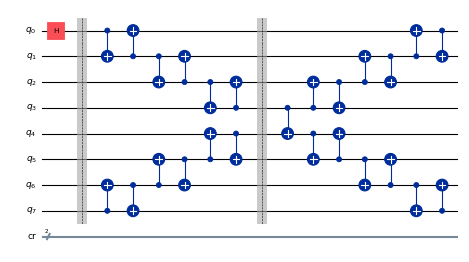

In [31]:
qc_uni.draw("mpl", fold=-1, scale=0.4)

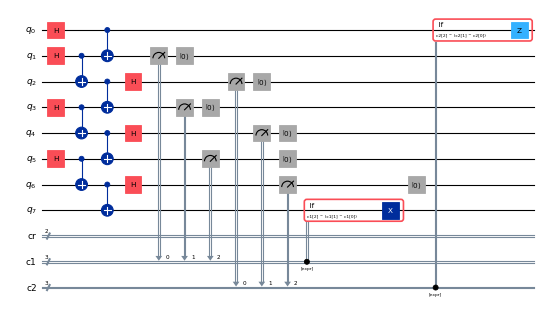

In [32]:
qc_dyn.draw("mpl", fold=-1, scale=0.4)

## Step 2 — Topology-aware qubit assignment (Problem 2.1)

| Topology | Bus strategy |
|---|---|
| **1D line** | Logical order `q0 — anc₁ — … — ancₙ — qₜ` |
| **2D square (`ibm_miami`)** | `shortest_path(backend, control, target)` on FakeMiami |
| **Heavy-hex (`ibm_yonsei`)** | Same on FakeBrisbane (ibm_yonsei proxy) |

`distance n = len(shortest_path) - 2`.

In [33]:
def find_connected_chain(coupling_map: CouplingMap, length: int) -> list[int]:
    num = coupling_map.size()
    neighbors = {i: set() for i in range(num)}
    for u, v in coupling_map.get_edges():
        neighbors[u].add(v)
        neighbors[v].add(u)

    found: list[int] = []

    def dfs(path: list[int], visited: set[int]) -> bool:
        nonlocal found
        if len(path) >= length:
            found = path[:length]
            return True
        for nbr in sorted(neighbors[path[-1]]):
            if nbr in visited:
                continue
            visited.add(nbr)
            path.append(nbr)
            if dfs(path, visited):
                return True
            path.pop()
            visited.remove(nbr)
        return False

    for start in range(num):
        if dfs([start], {start}):
            return found
    raise ValueError(f"No connected chain of length {length} on this coupling map")


def make_topology_backends():
    backends = {}

    line = CouplingMap.from_line(65)
    backends["1D line"] = GenericBackendV2(
        num_qubits=65,
        coupling_map=line,
        basis_gates=["cx", "rz", "sx", "x", "id"],
    )

    backends["2D square (ibm_miami)"] = backend_miami
    backends["heavy-hex (ibm_yonsei)"] = backend_yonsei

    return backends


TOPO_BACKENDS = make_topology_backends()
print("Topologies:", list(TOPO_BACKENDS))


Topologies: ['1D line', '2D square (ibm_miami)', 'heavy-hex (ibm_yonsei)']


In [34]:
def count_2q_gates(qc: QuantumCircuit) -> int:
    twoq = {"cx", "cz", "cy", "ch", "cp", "ecr", "rzz", "rxx", "ryy"}
    ops = qc.count_ops()
    return sum(ops.get(g, 0) for g in twoq)


def profile_logical(qc: QuantumCircuit) -> dict:
    ops = qc.count_ops()
    return {
        "num_qubits": qc.num_qubits,
        "depth": qc.depth(),
        "depth_2q": qc.depth(lambda inst: inst.operation.num_qubits == 2),
        "count_2q": count_2q_gates(qc),
        "measure": ops.get("measure", 0),
        "if_else": ops.get("if_else", 0),
        "swap": ops.get("swap", 0),
    }


def enable_dynamic_transpile(backend) -> None:
    if "if_else" not in backend.target.operation_names:
        backend.target.add_instruction(IfElseOp, name="if_else")
    if "reset" not in backend.target.operation_names:
        backend.target.add_instruction(Reset, name="reset")


def profile_transpiled(qc: QuantumCircuit, backend, *, chain: list[int] | None = None) -> dict:
    enable_dynamic_transpile(backend)
    if chain is not None:
        layout = Layout({qc.qubits[i]: chain[i] for i in range(qc.num_qubits)})
        pm = generate_preset_pass_manager(
            optimization_level=1, backend=backend, initial_layout=layout
        )
    else:
        pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    tqc = pm.run(qc)
    ops = tqc.count_ops()
    return {
        "num_qubits": tqc.num_qubits,
        "depth": tqc.depth(),
        "depth_2q": tqc.depth(lambda inst: inst.operation.num_qubits == 2),
        "count_2q": count_2q_gates(tqc),
        "measure": ops.get("measure", 0),
        "if_else": ops.get("if_else", 0),
        "swap": ops.get("swap", 0),
    }


def assign_chain_for_topology(topology: str, backend, n_logical: int) -> list[int]:
    if topology == "1D line":
        return list(range(n_logical))
    return find_connected_chain(backend.coupling_map, n_logical)


### Hardware layout mapping (Problem 2.1)

Given a **backend** and two physical qubits (**control**, **target**) for the long-range CNOT:

1. `shortest_path(backend, control, target)` — BFS shortest path on the coupling graph
2. `bus_chain_for_endpoints(...)` — ancilla bus = interior nodes; `distance n = len(path) - 2`
3. Transpile with that **initial layout**, then `plot_circuit_layout(..., view="physical", qubit_coordinates=None)`

In [35]:
def shortest_path(backend, qubit_a: int, qubit_b: int) -> list[int]:
    """Shortest path between two physical qubits on the backend coupling graph."""
    if qubit_a == qubit_b:
        return [qubit_a]

    coupling_map = backend.coupling_map
    neighbors: dict[int, set[int]] = {i: set() for i in range(coupling_map.size())}
    for u, v in coupling_map.get_edges():
        neighbors[u].add(v)
        neighbors[v].add(u)

    from collections import deque

    queue = deque([[qubit_a]])
    visited = {qubit_a}

    while queue:
        path = queue.popleft()
        node = path[-1]
        if node == qubit_b:
            return path
        for nbr in sorted(neighbors[node]):
            if nbr in visited:
                continue
            visited.add(nbr)
            queue.append(path + [nbr])

    raise ValueError(
        f"No path between physical qubits {qubit_a} and {qubit_b} on {backend.name}"
    )


def graph_hop_distance(backend, qubit_a: int, qubit_b: int) -> int:
    """Number of coupler hops (edges) on the shortest path."""
    return len(shortest_path(backend, qubit_a, qubit_b)) - 1


def bus_chain_for_endpoints(backend, control: int, target: int) -> tuple[list[int], int]:
    """Bus chain for long-range CNOT: control → ancillas → target.

    Returns (physical_chain, distance_n) where distance_n = len(chain) - 2.
    """
    chain = shortest_path(backend, control, target)
    if len(chain) < 2:
        raise ValueError("Need distinct control and target qubits")
    return chain, len(chain) - 2


def transpile_with_bus_layout(
    qc: QuantumCircuit,
    backend,
    chain: list[int],
    *,
    optimization_level: int = 1,
) -> QuantumCircuit:
    enable_dynamic_transpile(backend)
    layout = Layout({qc.qubits[i]: chain[i] for i in range(qc.num_qubits)})
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=backend,
        initial_layout=layout,
    )
    return pm.run(qc)


def print_bus_assignment(chain: list[int], distance: int) -> None:
    print(
        f"distance n={distance}  |  bus chain length {len(chain)}  |  graph hops {len(chain) - 1}"
    )
    print(f"  control q0      → physical {chain[0]}")
    if distance > 0:
        print(f"  ancilla bus     → physical {chain[1:-1]}")
    print(f"  target q_{{n+1}} → physical {chain[-1]}")


#### 2D square grid — physical layout (`ibm_miami` / FakeMiami)

Shortest-path bus between two chosen physical qubits.

In [36]:
backend = backend_miami
control_qubit, target_qubit = 0, 7

chain_sq, distance_sq = bus_chain_for_endpoints(backend, control_qubit, target_qubit)
print_bus_assignment(chain_sq, distance_sq)
print(f"shortest path: {chain_sq}")

core_dyn = lrcx(distance_sq, prep_barrier=False, pre_measure_barrier=False)
core_uni = cnot_unitary_swap(distance_sq)

isa_dyn = transpile_with_bus_layout(core_dyn, backend, chain_sq)
isa_uni = transpile_with_bus_layout(core_uni, backend, chain_sq)

print(f"dynamic 2Q depth: {isa_dyn.depth(lambda x: x.operation.num_qubits == 2)}")
print(f"unitary 2Q depth: {isa_uni.depth(lambda x: x.operation.num_qubits == 2)}")


distance n=6  |  bus chain length 8  |  graph hops 7
  control q0      → physical 0
  ancilla bus     → physical [1, 2, 3, 4, 5, 6]
  target q_{n+1} → physical 7
shortest path: [0, 1, 2, 3, 4, 5, 6, 7]
dynamic 2Q depth: 2
unitary 2Q depth: 13


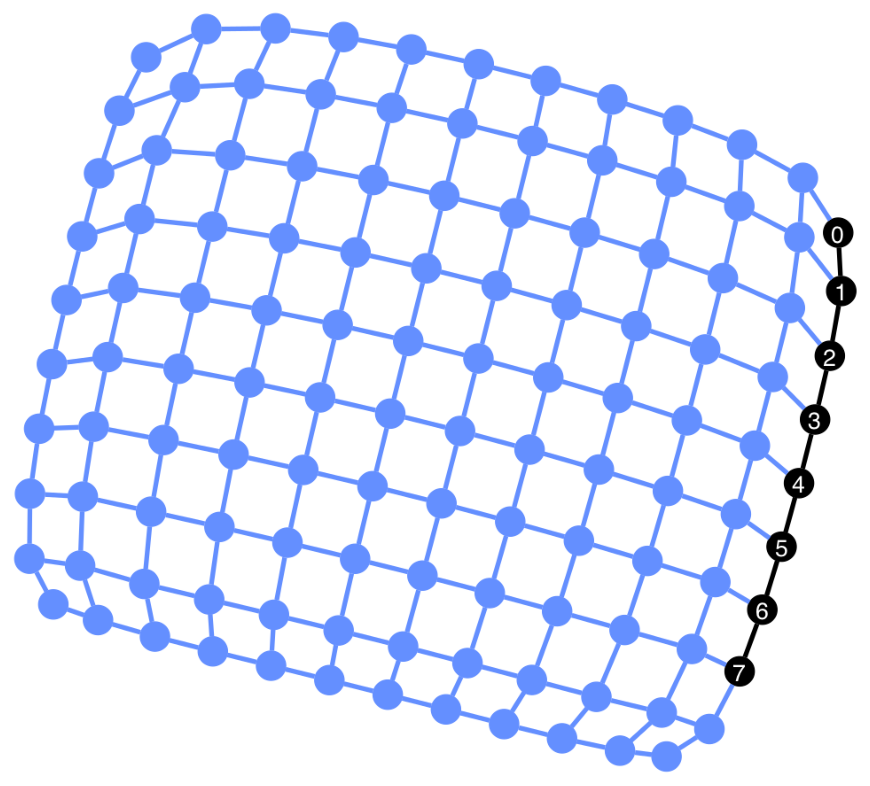

In [37]:
plot_circuit_layout(circuit=isa_dyn, backend=backend, view="physical", qubit_coordinates=None)


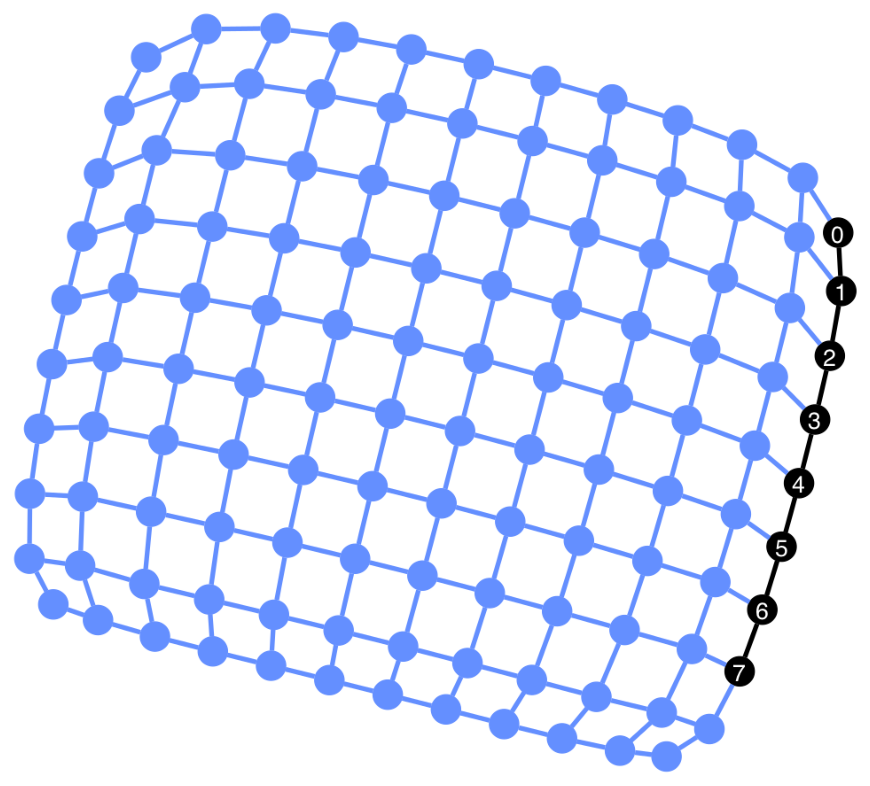

In [38]:
# Note: set qubit_coordinates=None to use the backend default gate-map layout.
plot_circuit_layout(circuit=isa_uni, backend=backend, view="physical", qubit_coordinates=None)


#### IBM heavy-hex — physical layout (`ibm_yonsei` / FakeBrisbane)

Same shortest-path workflow on the yonsei proxy backend.

In [39]:
backend = backend_yonsei
control_qubit, target_qubit = 0, 7

chain_hx, distance_hx = bus_chain_for_endpoints(backend, control_qubit, target_qubit)
print_bus_assignment(chain_hx, distance_hx)
print(f"shortest path: {chain_hx}")

core_dyn_hx = lrcx(distance_hx, prep_barrier=False, pre_measure_barrier=False)
core_uni_hx = cnot_unitary_swap(distance_hx)

isa_dyn_hx = transpile_with_bus_layout(core_dyn_hx, backend, chain_hx)
isa_uni_hx = transpile_with_bus_layout(core_uni_hx, backend, chain_hx)

print(f"dynamic 2Q depth: {isa_dyn_hx.depth(lambda x: x.operation.num_qubits == 2)}")
print(f"unitary 2Q depth: {isa_uni_hx.depth(lambda x: x.operation.num_qubits == 2)}")


distance n=6  |  bus chain length 8  |  graph hops 7
  control q0      → physical 0
  ancilla bus     → physical [1, 2, 3, 4, 5, 6]
  target q_{n+1} → physical 7
shortest path: [0, 1, 2, 3, 4, 5, 6, 7]
dynamic 2Q depth: 2
unitary 2Q depth: 13


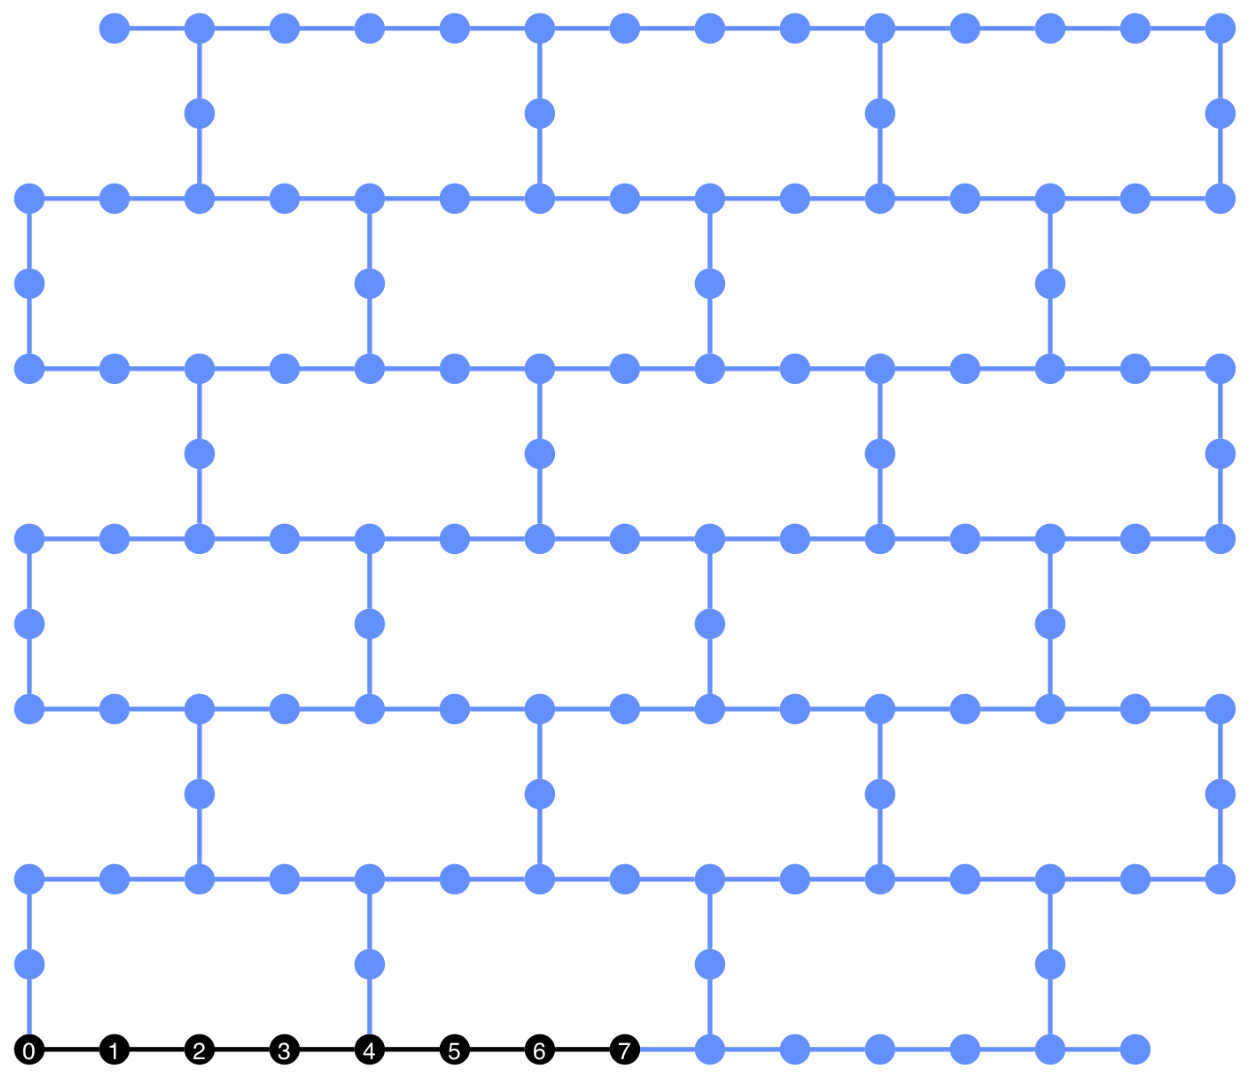

In [40]:
plot_circuit_layout(circuit=isa_dyn_hx, backend=backend, view="physical", qubit_coordinates=None)


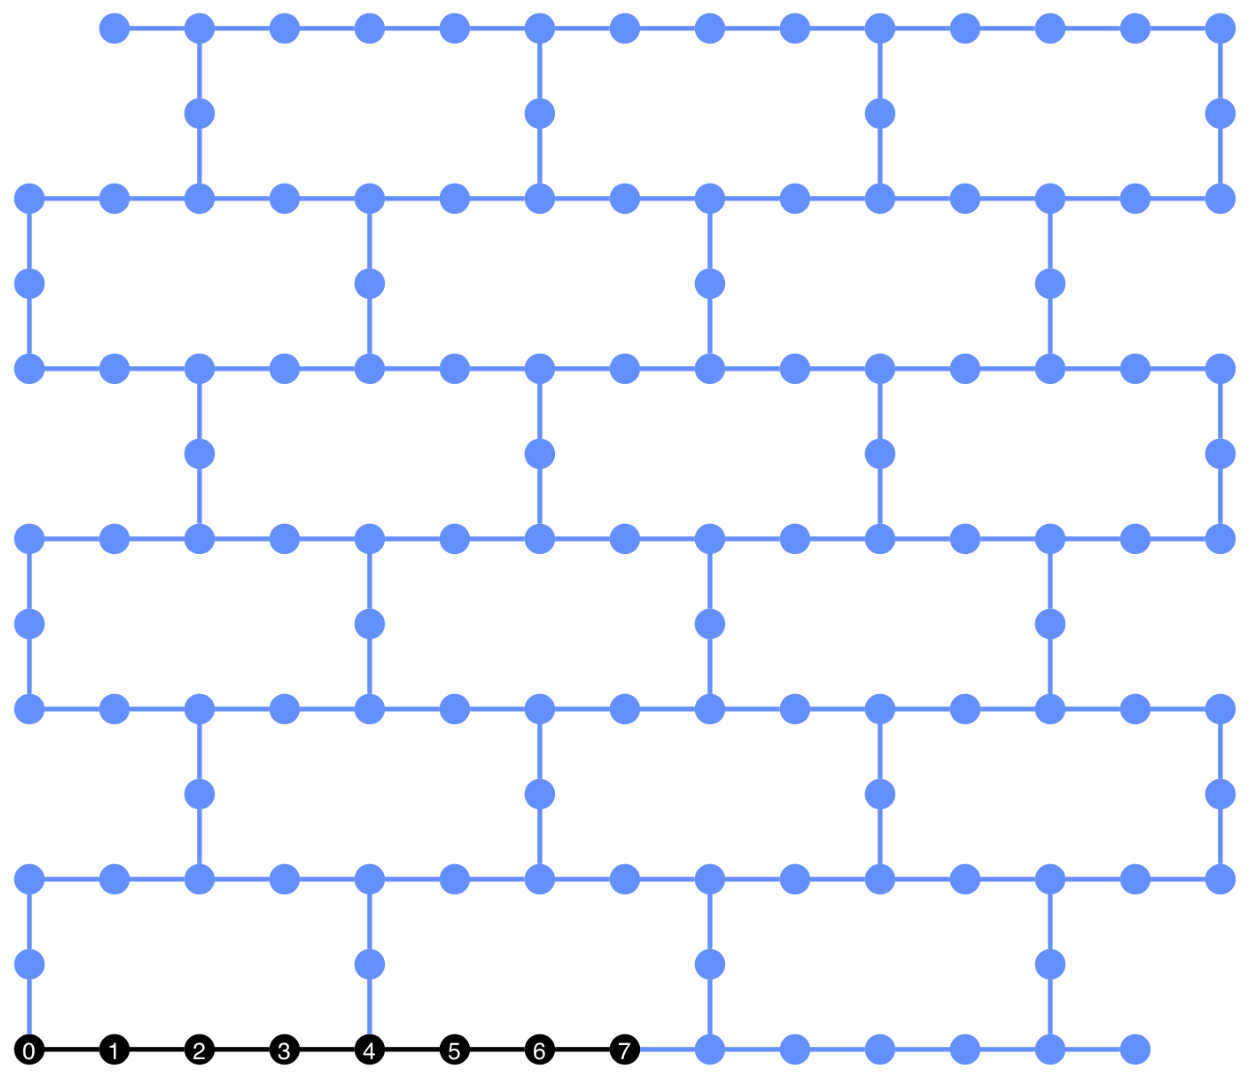

In [41]:
plot_circuit_layout(circuit=isa_uni_hx, backend=backend, view="physical", qubit_coordinates=None)


## Step 4 — Resource comparison vs distance (Problem 2.2)

For each topology we compare:

1. **Dynamic LRCX** with explicit bus layout (`chain` mapping)
2. **Unitary SWAP** manual circuit + transpiler
3. **Unitary default transpiler** (no manual SWAP, routing only)

Metrics: two-qubit gate count, 2Q depth, mid-circuit measurements (`if_else` proxy for dynamic).


In [42]:
DISTANCES = [0, 1, 2, 3, 6, 11, 16]
rows = []

for topology, backend in TOPO_BACKENDS.items():
    for distance in DISTANCES:
        n_logical = distance + 2
        try:
            chain = assign_chain_for_topology(topology, backend, n_logical)
        except ValueError as exc:
            print(f"skip {topology} distance={distance}: {exc}")
            continue

        dyn_core = lrcx(distance, prep_barrier=False, pre_measure_barrier=False)
        uni_core = cnot_unitary_swap(distance)

        dyn_prof = profile_logical(dyn_core)
        try:
            dyn_prof = profile_transpiled(dyn_core, backend, chain=chain)
        except Exception:
            pass

        uni_swap_prof = profile_transpiled(uni_core, backend, chain=chain)
        uni_auto_prof = profile_transpiled(uni_core, backend, chain=None)

        for variant, prof in [
            ("dynamic", dyn_prof),
            ("unitary_swap+layout", uni_swap_prof),
            ("unitary_transpiler", uni_auto_prof),
        ]:
            rows.append(
                {
                    "topology": topology,
                    "distance": distance,
                    "variant": variant,
                    **prof,
                }
            )

df_resources = pd.DataFrame(rows)
df_resources


,topology,distance,variant,num_qubits,depth,depth_2q,count_2q,measure,if_else,swap
0,1D line,0,dynamic,65,4,1,1,0,0,0
1,1D line,0,unitary_swap+layout,65,4,3,1,0,0,0
2,1D line,0,unitary_transpiler,65,4,3,1,0,0,0
3,1D line,1,dynamic,65,10,2,2,1,1,0
4,1D line,1,unitary_swap+layout,65,8,5,5,0,0,0
...,...,...,...,...,...,...,...,...,...,...
58,heavy-hex (ibm_yonsei),11,unitary_swap+layout,127,91,25,45,0,0,0
59,heavy-hex (ibm_yonsei),11,unitary_transpiler,127,91,25,45,0,0,0
60,heavy-hex (ibm_yonsei),16,dynamic,127,13,2,17,16,2,0
61,heavy-hex (ibm_yonsei),16,unitary_swap+layout,127,123,33,65,0,0,0


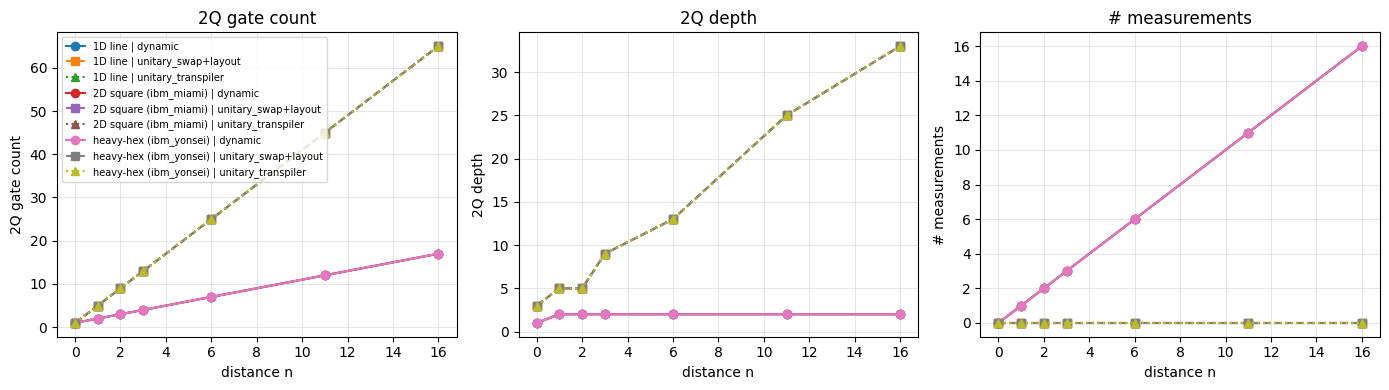

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [("count_2q", "2Q gate count"), ("depth_2q", "2Q depth"), ("measure", "# measurements")]

for ax, (col, title) in zip(axes, metrics):
    for topology in df_resources["topology"].unique():
        sub = df_resources[df_resources["topology"] == topology]
        for variant, style in [
            ("dynamic", "o-"),
            ("unitary_swap+layout", "s--"),
            ("unitary_transpiler", "^:"),
        ]:
            s = sub[sub["variant"] == variant]
            if s.empty:
                continue
            ax.plot(s["distance"], s[col], style, label=f"{topology} | {variant}")
    ax.set_xlabel("distance n")
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)
    ax.set_title(title)

axes[0].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()


## Step 5 — Schematic bus-chain view (supplement)

For a compact schematic of the chosen bus paths (without full transpiled ISA layout), see the plots below. Detailed **physical** mappings are in Step 2.1 above.


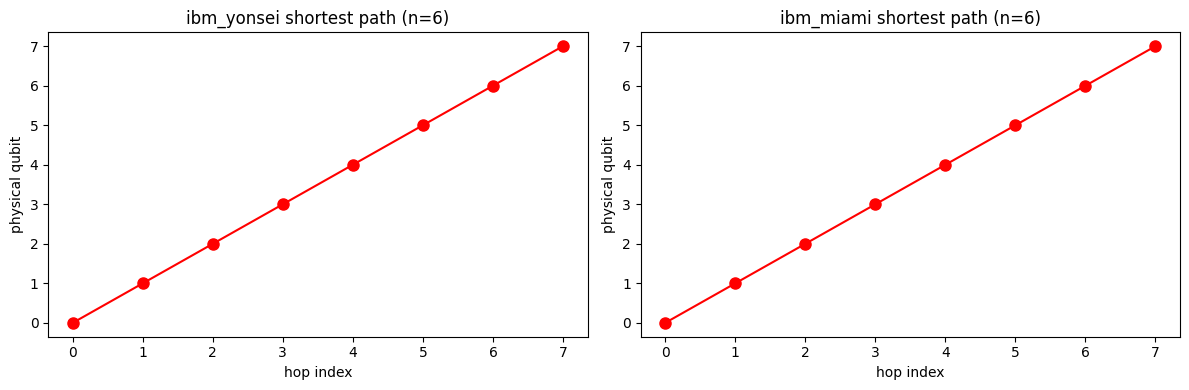

ibm_miami: [0, 1, 2, 3, 4, 5, 6, 7]
ibm_yonsei: [0, 1, 2, 3, 4, 5, 6, 7]


In [44]:
def plot_bus_chain(chain, rows=None, cols=None, *, ax, title: str):
    if rows is not None and cols is not None:
        xs = [q % cols for q in chain]; ys = [q // cols for q in chain]
        ax.scatter(xs, ys, c="steelblue", s=80, zorder=3)
        for i in range(len(chain)-1):
            ax.plot([xs[i], xs[i+1]], [ys[i], ys[i+1]], "crimson", linewidth=2, zorder=2)
        ax.set_xticks(range(cols)); ax.set_yticks(range(rows)); ax.grid(alpha=0.3)
    else:
        ax.plot(range(len(chain)), chain, "o-r", markersize=8)
        ax.set_xlabel("hop index"); ax.set_ylabel("physical qubit")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
chain_sq, n_sq = bus_chain_for_endpoints(backend_miami, 0, 7)
chain_hx, n_hx = bus_chain_for_endpoints(backend_yonsei, 0, 7)
plot_bus_chain(chain_hx, ax=axes[0], title=f"ibm_yonsei shortest path (n={n_hx})")
plot_bus_chain(chain_sq, ax=axes[1], title=f"ibm_miami shortest path (n={n_sq})")
plt.tight_layout(); plt.show()
print("ibm_miami:", chain_sq)
print("ibm_yonsei:", chain_hx)


## Discussion (Problem 2.1–2.2)

**Square grid:** A snake path uses only nearest-neighbor grid edges; ancillas fill every hop between control and target. SWAP overhead is minimal when the path follows the grid.

**Heavy-hex:** Logical bus qubits map to a DFS-found connected chain; non-local index gaps are fine as long as couplers exist. Dynamic circuits avoid routing SWAPs but pay **mid-circuit measurement + feed-forward** latency.

**Unitary vs dynamic:** At small `n`, unitary SWAP depth is modest. As `n` grows, unitary 2Q depth scales O(n) while dynamic 2Q depth stays O(1); the crossover depends on `λ_idle`, `λ_CNOT`, `λ_meas` — analyzed in **Problem 3** (last section of this notebook).

## References

1. 2026 Quantum Hackathon — Dynamic Circuits (지정문제 4)
2. E. Bäumer *et al.*, PRX Quantum **5**, 030339 (2024)
3. IBM Quantum tutorial: *Long-range entanglement with dynamic circuits*


## Problem 3 — Noise impact on dynamic long-range CNOT

Fidelity metric: **average gate fidelity** $F_{\mathrm{avg}}$ from paper Appendix C.2,
computed as $F_{\mathrm{avg}} = (d F_{\mathrm{proc}} + 1)/(d+1)$ with $d=4$ (Eq. C13).

$$
\lambda_{\mathrm{tot}} = t_{\mathrm{idle}}\,\lambda_{\mathrm{idle}} + N_{\mathrm{CNOT}}\,\lambda_{\mathrm{CNOT}} + N_{\mathrm{meas}}\,\lambda_{\mathrm{meas}}
$$


### Step 3.1 — Noisy verification (custom Aer backends)

Uses **average gate fidelity** $F_{\mathrm{avg}}$ (Appendix C, Eq. C13), not raw process fidelity.

Tune `MIAMI_OVERRIDES` / `YONSEI_OVERRIDES` in Setup (same API as `custom_backend.ipynb`).


In [45]:
# Step 3.1 — Noisy verification (average gate fidelity F_avg, Appendix C Eq. C13)

# IMPORTANT: custom noise model can crash Aer for dynamic if_else circuits on some machines.
USE_CUSTOM_NOISE_BACKEND = False


def run_noisy_fidelity(reference_backend, backend_sim, distance: int, label: str) -> None:
    pm0 = generate_preset_pass_manager(optimization_level=0, backend=reference_backend)
    circuits = certification_circuits(distance, "dynamic") + certification_circuits(distance, "unitary")
    isa = pm0.run(circuits)

    run_backend = backend_sim if USE_CUSTOM_NOISE_BACKEND else AerSimulator.from_backend(reference_backend)
    run_label = label if USE_CUSTOM_NOISE_BACKEND else f"{label} (safe)"

    result = run_backend.run(isa, shots=SHOTS).result()

    f_dyn = compute_fidelity(result.get_counts(0), result.get_counts(1), result.get_counts(2))
    f_uni = compute_fidelity(result.get_counts(3), result.get_counts(4), result.get_counts(5))
    print(f"{run_label:20s} | dynamic F_avg={f_dyn:.4f}  unitary F_avg={f_uni:.4f}  (distance={distance})")


# Sanity check: ideal Bell-state counts -> F_proc=1, F_avg=1
_ideal_xx = {"00": 1, "11": 1}
_ideal_yy = {"01": 1, "10": 1}
_ideal_zz = {"00": 1, "11": 1}
print(
    "Fidelity metric:",
    f"F_proc={compute_process_fidelity(_ideal_xx, _ideal_yy, _ideal_zz):.4f},",
    f"F_avg={compute_fidelity(_ideal_xx, _ideal_yy, _ideal_zz):.4f}",
    "(expect 1.000 / 1.000)",
)

run_noisy_fidelity(backend_miami, backend_miami_sim, distance_sq, "fake_miami")
run_noisy_fidelity(backend_yonsei, backend_yonsei_sim, distance_hx, "fake_yonsei")


Fidelity metric: F_proc=1.0000, F_avg=1.0000 (expect 1.000 / 1.000)
fake_miami (safe)    | dynamic F_avg=0.8620  unitary F_avg=0.5828  (distance=6)
fake_yonsei (safe)   | dynamic F_avg=0.7117  unitary F_avg=0.5839  (distance=6)


### Step 3.2 — T1/T2 grid: fidelity & error budget (distance = 6)

Sweep **T1** (x-axis) and **T2** (y-axis) using the fake-backend noise overrides from the setup cell. For each combination at **distance `n = 6`** we compute:

1. **Average gate fidelity** $F_{\mathrm{avg}}$ of the dynamic LRCX (Monte-Carlo certification, Appendix C.2; Eq. C13).
2. **Total error budget** from the paper (Appendix B.1):

$$\lambda_{\mathrm{tot}} = t_{\mathrm{idle}}\,\lambda_{\mathrm{idle}} + N_{\mathrm{CNOT}}\,\lambda_{\mathrm{CNOT}} + N_{\mathrm{meas}}\,\lambda_{\mathrm{meas}}$$

Resource counts (`t_idle`, `N_CNOT`, `N_meas`) come from the transpiled dynamic circuit; $\lambda$ rates are derived from the backend calibration and the swept T1/T2 / readout settings.

Heatmaps use a grayscale colormap: **black = low**, **white = high**.

> **Stability note:** Rebuilding the full custom noise model and batch-running dynamic `if_else` circuits for every grid point can crash the Jupyter kernel (Aer segfault). The sweep below reuses one simulator, uses a **lightweight thermal + readout noise model** (T1/T2 still swept), and runs the three certification circuits **one at a time**.



fake_miami (ibm_miami) | backend=fake_miami | distance=6
  resources: t_idle=2.32, N_CNOT=7, N_meas=6
  readout error (median × scale) = 0.0249
  sweep grid: 6×6 = 36 points
  progress 6/36 | T1=528 µs, T2=97 µs | F=0.813
  progress 12/36 | T1=528 µs, T2=155 µs | F=0.834
  progress 18/36 | T1=528 µs, T2=213 µs | F=0.821
  progress 24/36 | T1=528 µs, T2=271 µs | F=0.829
  progress 30/36 | T1=528 µs, T2=329 µs | F=0.840
  progress 36/36 | T1=528 µs, T2=387 µs | F=0.810


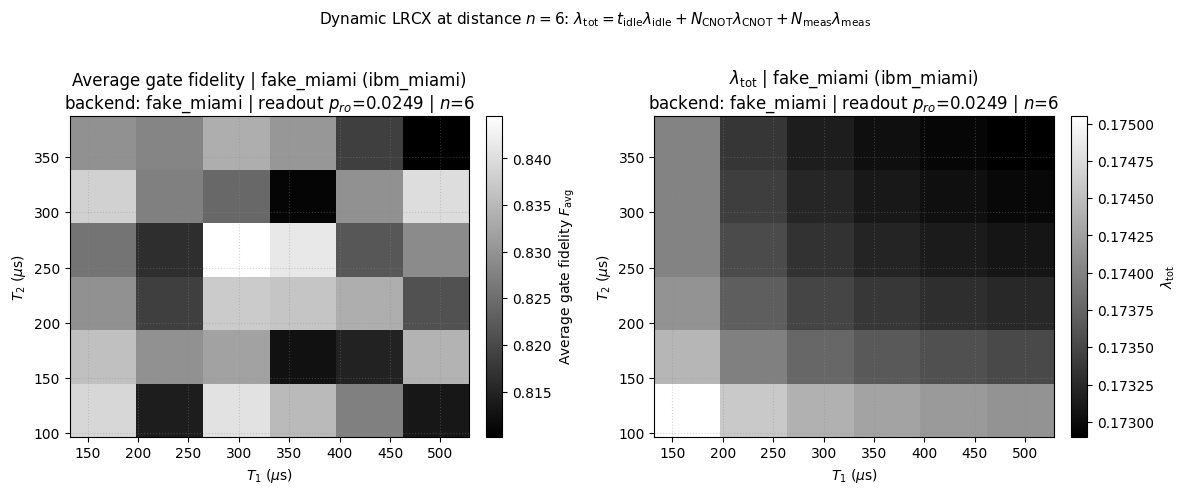


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance=6
  resources: t_idle=2.18, N_CNOT=7, N_meas=6
  readout error (median × scale) = 0.0394
  sweep grid: 6×6 = 36 points
  progress 6/36 | T1=371 µs, T2=60 µs | F=0.640
  progress 12/36 | T1=371 µs, T2=96 µs | F=0.645
  progress 18/36 | T1=371 µs, T2=132 µs | F=0.660
  progress 24/36 | T1=371 µs, T2=168 µs | F=0.663
  progress 30/36 | T1=371 µs, T2=204 µs | F=0.674
  progress 36/36 | T1=371 µs, T2=240 µs | F=0.649


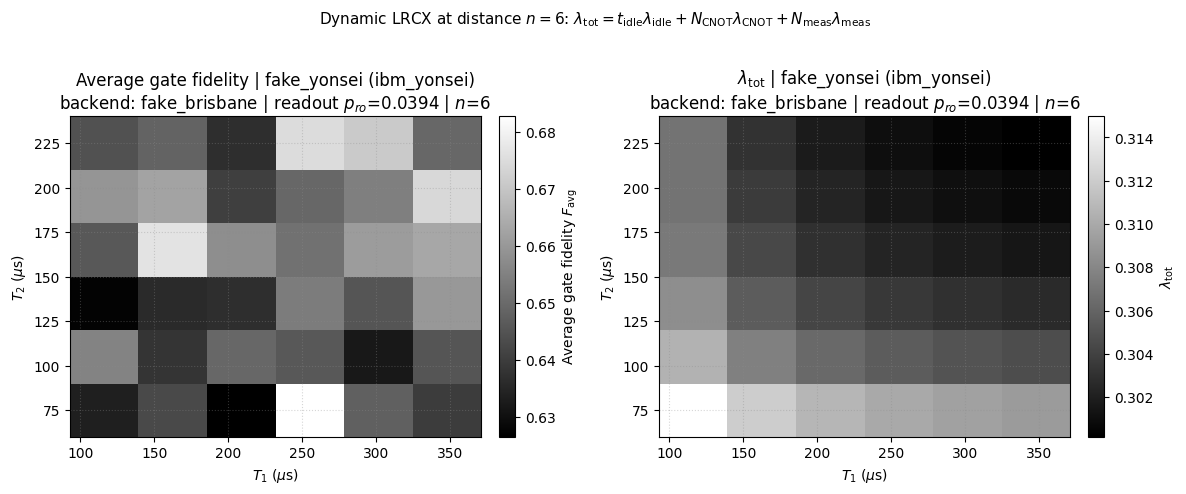

In [46]:
# ------------------------- T1/T2 sweep heatmaps (distance = 6) -------------------------

import gc

SWEEP_DISTANCE = DISTANCE_DEMO  # n = 6
SWEEP_SHOTS = 512
SWEEP_GRID_POINTS = 6  # 6×6 is stable; increase only if your machine handles it
 
TWO_Q_NAMES = {"cx", "cz", "cy", "ecr", "rzz", "rxx", "ryy"}
SWEEP_GATE_NAMES = {"id", "sx", "x", "cx", "cz", "ecr", "reset"}


def median_2q_duration_s(backend) -> float:
    target = backend.target
    durations = []
    for name in TWO_Q_NAMES:
        if name not in target.operation_names:
            continue
        for qargs, props in target[name].items():
            if props is not None and props.duration:
                durations.append(props.duration)
    if not durations:
        return 68e-9
    return float(median(durations))


def median_gate_error(backend) -> float:
    target = backend.target
    errors = []
    for name in TWO_Q_NAMES:
        if name not in target.operation_names:
            continue
        for _, props in target[name].items():
            if props is not None and props.error is not None:
                errors.append(props.error)
    return float(median(errors)) if errors else 0.01


def median_readout_error(backend, qubits: list[int] | None = None) -> float:
    target = backend.target
    if "measure" not in target.operation_names:
        return 0.02
    qubits = qubits or list(range(min(20, len(target.qubit_properties))))
    errors = []
    for q in qubits:
        props = target["measure"].get((q,))
        if props is not None and props.error is not None:
            errors.append(props.error)
    return float(median(errors)) if errors else 0.02


def gate_duration_s(backend, op_name: str, qubits: tuple[int, ...]) -> float:
    target = backend.target
    if op_name in target.operation_names:
        props = target[op_name].get(qubits)
        if props is not None and props.duration:
            return props.duration
    if op_name in {"h", "x", "sx", "rz", "id"} and op_name in target.operation_names:
        props = target[op_name].get((qubits[0],))
        if props is not None and props.duration:
            return props.duration
    if op_name == "measure" and "measure" in target.operation_names:
        props = target["measure"].get((qubits[0],))
        if props is not None and props.duration:
            return props.duration
    if op_name == "if_else":
        return median_2q_duration_s(backend)
    return 0.0



# --- Error-budget helpers (dynamic_cnot_noise_problem3.ipynb style) ---
FEEDFORWARD_TIME_NS = 700.0
DEFAULT_BUDGET_PARAMS = {
    "mu": 3.65,
    "lambda_idle": 0.03,
    "lambda_cnot": 0.02,
    "lambda_meas": 0.03,
}


def _error_probability_to_lambda(probability: float) -> float:
    """Small-error conversion from calibration probability to Lindblad-style rate."""
    p = min(max(float(probability), 0.0), 1.0 - 1e-12)
    return float(-np.log(1.0 - p))


def _idle_lambda_per_cnot_time(t1_ns: float, t2_ns: float, cnot_time_ns: float) -> float:
    """Appendix-G-inspired idle rate over one two-qubit-gate duration."""
    if min(t1_ns, t2_ns, cnot_time_ns) <= 0:
        return DEFAULT_BUDGET_PARAMS["lambda_idle"]
    return float(cnot_time_ns * (1.0 / (2.0 * t1_ns) + 1.0 / (2.0 * t2_ns)))


def add_budget_terms(resource_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Match dynamic_cnot_noise_problem3.ipynb budget table format."""
    out = resource_df.copy()
    out["lambda_idle_term"] = out["t_idle"] * params["lambda_idle"]
    out["lambda_cnot_term"] = out["N_CNOT"] * params["lambda_cnot"]
    out["lambda_meas_term"] = out["N_meas"] * params["lambda_meas"]
    out["lambda_total"] = (
        out["lambda_idle_term"]
        + out["lambda_cnot_term"]
        + out["lambda_meas_term"]
    )
    out["process_fidelity_lower_bound"] = np.exp(-out["lambda_total"])
    return out


def build_budget_params(
    backend,
    overrides: HardwareNoiseOverrides,
    t1_us: float,
    t2_us: float,
    chain: list[int],
    feedforward_time_ns: float = FEEDFORWARD_TIME_NS,
) -> dict:
    """Backend-calibrated budget lambdas with optional T1/T2 / error overrides."""
    t1_ns = float(t1_us) * 1e3
    t2_ns = min(float(t2_us) * 1e3, 2.0 * t1_ns)
    time_2q_ns = median_2q_duration_s(backend) * 1e9

    two_q_error = min(
        median_gate_error(backend) * overrides.gate_error_scale,
        1.0 - 1e-12,
    )
    readout_p = min(
        median_readout_error(backend, chain) * overrides.readout_error_scale,
        1.0 - 1e-12,
    )

    meas_durs = [
        props.duration
        for qargs, props in backend.target["measure"].items()
        if props is not None and props.duration
    ]
    time_meas_ns = float(median(meas_durs)) * 1e9 if meas_durs else 1200.0

    return {
        "mu": (time_meas_ns + feedforward_time_ns) / time_2q_ns,
        "lambda_idle": _idle_lambda_per_cnot_time(t1_ns, t2_ns, time_2q_ns),
        "lambda_cnot": _error_probability_to_lambda(two_q_error),
        "lambda_meas": _error_probability_to_lambda(readout_p),
    }


def compute_lambda_total(resources: dict, budget_params: dict) -> float:
    row = pd.DataFrame(
        [
            {
                "t_idle": resources["t_idle"],
                "N_CNOT": resources["N_CNOT"],
                "N_meas": resources["N_meas"],
            }
        ]
    )
    return float(add_budget_terms(row, budget_params)["lambda_total"].iloc[0])


def estimate_mu(backend) -> float:
    """Measurement + feed-forward latency in units of median 2Q gate time."""
    time_2q_ns = median_2q_duration_s(backend) * 1e9
    meas_durs = [
        props.duration
        for qargs, props in backend.target["measure"].items()
        if props is not None and props.duration
    ]
    time_meas_ns = float(median(meas_durs)) * 1e9 if meas_durs else 2280.0
    return (time_meas_ns + FEEDFORWARD_TIME_NS) / time_2q_ns

def idle_time_cnot_units(qc: QuantumCircuit, backend) -> float:
    """Sum of per-qubit idle intervals, expressed in median 2Q gate times."""
    t_2q = median_2q_duration_s(backend)
    if t_2q <= 0:
        return 0.0

    times = [0.0] * qc.num_qubits
    idle_s = 0.0

    for item in qc.data:
        op = item.operation
        if getattr(op, "name", None) == "barrier":
            continue
        qidx = [qc.find_bit(q).index for q in item.qubits]
        phys = tuple(qidx)
        dur = gate_duration_s(backend, op.name, phys)
        start = max(times[q] for q in qidx)
        for q in qidx:
            idle_s += start - times[q]
            times[q] = start + dur

    return idle_s / t_2q


def error_budget_resources(qc: QuantumCircuit, backend, distance: int) -> dict[str, float]:
    ops = qc.count_ops()
    t_idle = idle_time_cnot_units(qc, backend)
    if t_idle <= 0:
        t_idle = 2 * estimate_mu(backend) + 2  # paper dynamic fallback

    return {
        "t_idle": t_idle,
        "N_CNOT": float(count_2q_gates(qc)),
        "N_meas": float(ops.get("measure", 0)),
        "mu": estimate_mu(backend),
    }


def transpiled_dynamic_core(backend, distance: int, chain: list[int]) -> QuantumCircuit:
    core = lrcx(distance, prep_barrier=False, pre_measure_barrier=False)
    return transpile_with_bus_layout(core, backend, chain)


def build_sweep_noise_model(
    reference_backend,
    overrides: HardwareNoiseOverrides,
    t1_us: float,
    t2_us: float,
) -> NoiseModel:
    """Lightweight T1/T2 sweep noise model (thermal + readout only).

  Avoids composing depolarizing + thermal channels on every calibrated edge,
  which can segfault Aer when repeated hundreds of times on dynamic circuits.
    """
    t1_s = t1_us * 1e-6
    t2_s = min(t2_us * 1e-6, 2 * t1_s)
    noise_model = NoiseModel()
    target = reference_backend.target

    if overrides.include_thermal_relaxation:
        for gate_name in SWEEP_GATE_NAMES:
            if gate_name not in target.operation_names:
                continue
            for qargs, properties in target[gate_name].items():
                if qargs is None or properties is None or not properties.duration:
                    continue
                try:
                    if gate_name == "reset":
                        combined = depolarizing_error(overrides.reset_error_rate, 1)
                    else:
                        channels = [
                            thermal_relaxation_error(t1_s, t2_s, properties.duration)
                            for _ in qargs
                        ]
                        combined = channels[0]
                        for channel in channels[1:]:
                            combined = combined.tensor(channel)
                    noise_model.add_quantum_error(
                        combined, [gate_name], list(qargs), warnings=False
                    )
                except Exception:
                    continue

    if overrides.include_readout_error and "measure" in target.operation_names:
        for qargs, properties in target["measure"].items():
            if qargs is None or len(qargs) != 1 or properties is None or properties.error is None:
                continue
            readout_p = _clip_probability(
                properties.error * overrides.readout_error_scale, 1.0
            )
            ro_err = ReadoutError(
                [[1 - readout_p, readout_p], [readout_p, 1 - readout_p]]
            )
            noise_model.add_readout_error(ro_err, [qargs[0]])

    return noise_model


def make_sweep_simulator(reference_backend) -> AerSimulator:
    sim = AerSimulator.from_backend(reference_backend)
    sim.set_options(max_parallel_experiments=1)
    return sim


def transpiled_certification_circuits(
    reference_backend,
    distance: int,
    chain: list[int],
) -> list[QuantumCircuit]:
    circuits = certification_circuits(distance, "dynamic")
    return [transpile_with_bus_layout(c, reference_backend, chain) for c in circuits]


def run_dynamic_fidelity(
    simulator: AerSimulator,
    reference_backend,
    overrides: HardwareNoiseOverrides,
    isa_circuits: list[QuantumCircuit],
    t1_us: float,
    t2_us: float,
) -> float:
    noise_model = build_sweep_noise_model(reference_backend, overrides, t1_us, t2_us)
    simulator.set_options(noise_model=noise_model)

    counts = []
    for circuit in isa_circuits:
        result = simulator.run(circuit, shots=SWEEP_SHOTS).result()
        counts.append(result.get_counts())

    return compute_fidelity(counts[0], counts[1], counts[2])


def make_t1_t2_grids(reference_backend, n_points: int = SWEEP_GRID_POINTS) -> tuple[np.ndarray, np.ndarray]:
    summary = summarize_backend_t1_t2(reference_backend)
    t1_center = summary["median_t1_us"]
    t2_center = summary["median_t2_us"]

    t1_grid = np.linspace(max(20.0, 0.4 * t1_center), 1.6 * t1_center, n_points)
    t2_grid = np.linspace(max(15.0, 0.4 * t2_center), 1.6 * t2_center, n_points)
    return t1_grid, t2_grid


def sweep_backend_heatmaps(
    display_name: str,
    reference_backend,
    overrides: HardwareNoiseOverrides,
    distance: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, dict]:
    n_logical = distance + 2
    topology_key = (
        "2D square (ibm_miami)"
        if "miami" in display_name
        else "heavy-hex (ibm_yonsei)"
    )
    chain = assign_chain_for_topology(topology_key, reference_backend, n_logical)

    isa_dyn = transpiled_dynamic_core(reference_backend, distance, chain)
    resources = error_budget_resources(isa_dyn, reference_backend, distance)

    isa_cert = transpiled_certification_circuits(reference_backend, distance, chain)
    simulator = make_sweep_simulator(reference_backend)

    t1_grid, t2_grid = make_t1_t2_grids(reference_backend)
    fidelity_map = np.zeros((len(t2_grid), len(t1_grid)))
    lambda_map = np.zeros_like(fidelity_map)

    readout_p = median_readout_error(reference_backend, chain) * overrides.readout_error_scale
    n_points = len(t1_grid) * len(t2_grid)

    print(f"\n{display_name} | backend={reference_backend.name} | distance={distance}")
    print(f"  resources: t_idle={resources['t_idle']:.2f}, N_CNOT={resources['N_CNOT']:.0f}, N_meas={resources['N_meas']:.0f}")
    print(f"  readout error (median × scale) = {readout_p:.4f}")
    print(f"  sweep grid: {len(t1_grid)}×{len(t2_grid)} = {n_points} points")

    for i, t2_us in enumerate(t2_grid):
        for j, t1_us in enumerate(t1_grid):
            budget_params = build_budget_params(reference_backend, overrides, t1_us, t2_us, chain)
            lambda_map[i, j] = compute_lambda_total(resources, budget_params)
            fidelity_map[i, j] = run_dynamic_fidelity(
                simulator,
                reference_backend,
                overrides,
                isa_cert,
                t1_us,
                t2_us,
            )

            point = i * len(t1_grid) + j + 1
            if point % max(1, n_points // 6) == 0 or point == n_points:
                print(f"  progress {point}/{n_points} | T1={t1_us:.0f} µs, T2={t2_us:.0f} µs | F={fidelity_map[i,j]:.3f}")

        gc.collect()

    meta = {
        "backend_name": reference_backend.name,
        "display_name": display_name,
        "readout_error": readout_p,
        "resources": resources,
        "chain": chain,
    }
    return t1_grid, t2_grid, fidelity_map, lambda_map, meta


def plot_t1_t2_heatmaps(
    t1_grid: np.ndarray,
    t2_grid: np.ndarray,
    fidelity_map: np.ndarray,
    lambda_map: np.ndarray,
    meta: dict,
) -> None:
    extent = [t1_grid[0], t1_grid[-1], t2_grid[0], t2_grid[-1]]
    backend_label = meta["display_name"]
    ro_label = meta["readout_error"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    panels = [
        (fidelity_map, r"Average gate fidelity $F_{\mathrm{avg}}$", "Average gate fidelity"),
        (lambda_map, r"$\lambda_{\mathrm{tot}}$", r"$\lambda_{\mathrm{tot}}$"),
    ]

    for ax, (data, cbar_label, panel_title) in zip(axes, panels):
        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap="gray",
            vmin=float(np.min(data)),
            vmax=float(np.max(data)),
        )
        ax.set_xlabel(r"$T_1$ ($\mu$s)")
        ax.set_ylabel(r"$T_2$ ($\mu$s)")
        ax.set_title(
            f"{panel_title} | {backend_label}\n"
            f"backend: {meta['backend_name']} | readout $p_{{ro}}$={ro_label:.4f} | $n$={SWEEP_DISTANCE}"
        )
        ax.grid(True, color="0.55", alpha=0.35, linestyle=":")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    fig.suptitle(
        r"Dynamic LRCX at distance $n=6$: $\lambda_{\mathrm{tot}} = t_{\mathrm{idle}}\lambda_{\mathrm{idle}} + N_{\mathrm{CNOT}}\lambda_{\mathrm{CNOT}} + N_{\mathrm{meas}}\lambda_{\mathrm{meas}}$",
        y=1.02,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


BACKEND_SWEEP_CONFIGS = [
    ("fake_miami (ibm_miami)", backend_miami, MIAMI_OVERRIDES),
    ("fake_yonsei (ibm_yonsei)", backend_yonsei, YONSEI_OVERRIDES),
]

for display_name, ref_backend, overrides in BACKEND_SWEEP_CONFIGS:
    t1_g, t2_g, f_map, l_map, meta = sweep_backend_heatmaps(
        display_name,
        ref_backend,
        overrides,
        SWEEP_DISTANCE,
    )
    plot_t1_t2_heatmaps(t1_g, t2_g, f_map, l_map, meta)


### Step 3.3 — Distance vs measurement-noise sweep

Sweep **distance `n`** (x-axis) and **measurement noise scale** (y-axis).

For each fake backend we compute and plot:
1. **Dynamic LRCX** fidelity + $\lambda_{\mathrm{tot}}$
2. **Unitary SWAP** fidelity + $\lambda_{\mathrm{tot}}$
3. **Winner map** (blue = unitary higher, red = dynamic higher)



fake_miami (ibm_miami) | backend=fake_miami
  grid: distance=[0, 1, 2, 3, 4, 5, 6], meas_scale=[0.5, 0.833, 1.167, 1.5, 1.833, 2.167, 2.5]
  progress 8/49 | n=0, readout~0.0125, F_dyn=0.977, F_uni=0.976
  progress 16/49 | n=1, readout~0.0187, F_dyn=0.948, F_uni=0.948
  progress 24/49 | n=2, readout~0.0264, F_dyn=0.919, F_uni=0.942
  progress 32/49 | n=3, readout~0.0293, F_dyn=0.879, F_uni=0.931
  progress 40/49 | n=4, readout~0.0358, F_dyn=0.827, F_uni=0.923
  progress 48/49 | n=5, readout~0.0403, F_dyn=0.801, F_uni=0.908
  progress 49/49 | n=6, readout~0.0415, F_dyn=0.741, F_uni=0.883


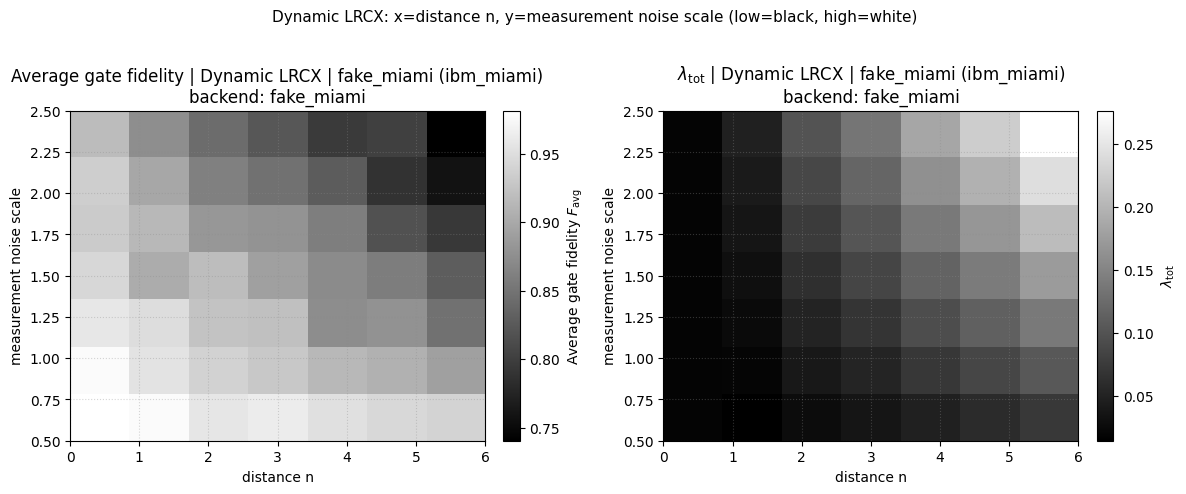

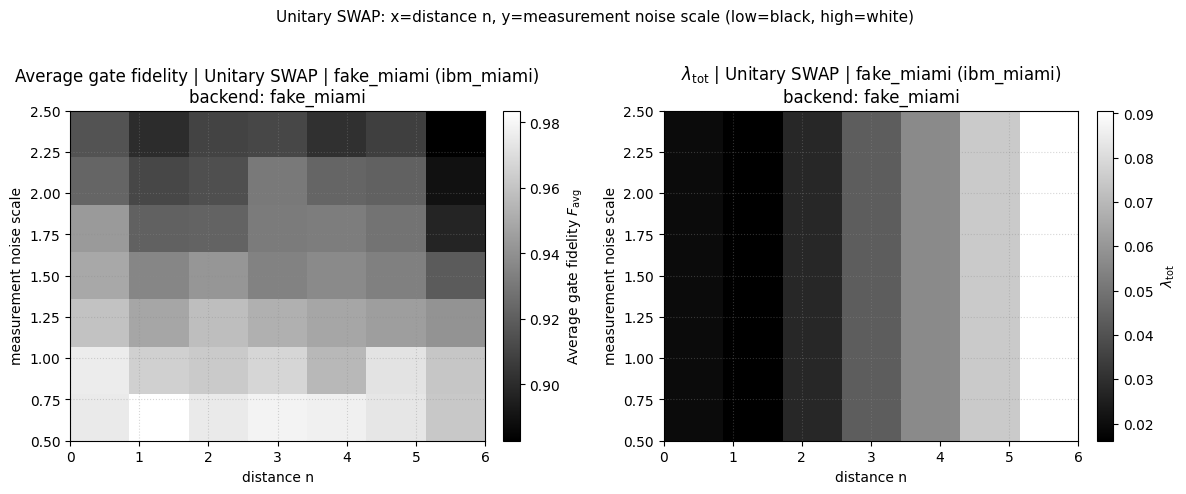

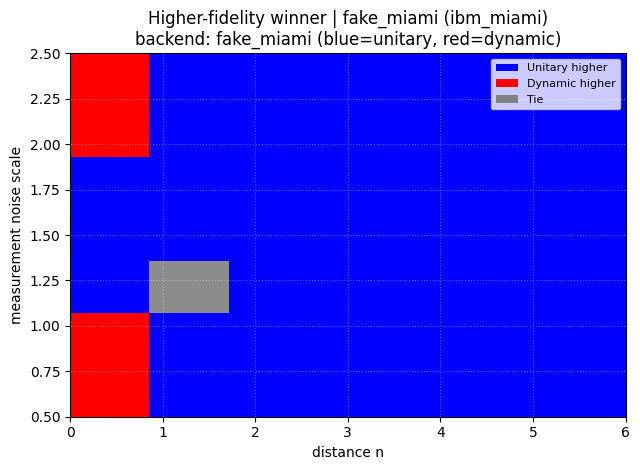


fake_yonsei (ibm_yonsei) | backend=fake_brisbane
  grid: distance=[0, 1, 2, 3, 4, 5, 6], meas_scale=[0.5, 0.833, 1.167, 1.5, 1.833, 2.167, 2.5]
  progress 8/49 | n=0, readout~0.0245, F_dyn=0.928, F_uni=0.939
  progress 16/49 | n=1, readout~0.0325, F_dyn=0.905, F_uni=0.938
  progress 24/49 | n=2, readout~0.0414, F_dyn=0.857, F_uni=0.895
  progress 32/49 | n=3, readout~0.0501, F_dyn=0.798, F_uni=0.868
  progress 40/49 | n=4, readout~0.0598, F_dyn=0.478, F_uni=0.518
  progress 48/49 | n=5, readout~0.0684, F_dyn=0.545, F_uni=0.818
  progress 49/49 | n=6, readout~0.0656, F_dyn=0.518, F_uni=0.821


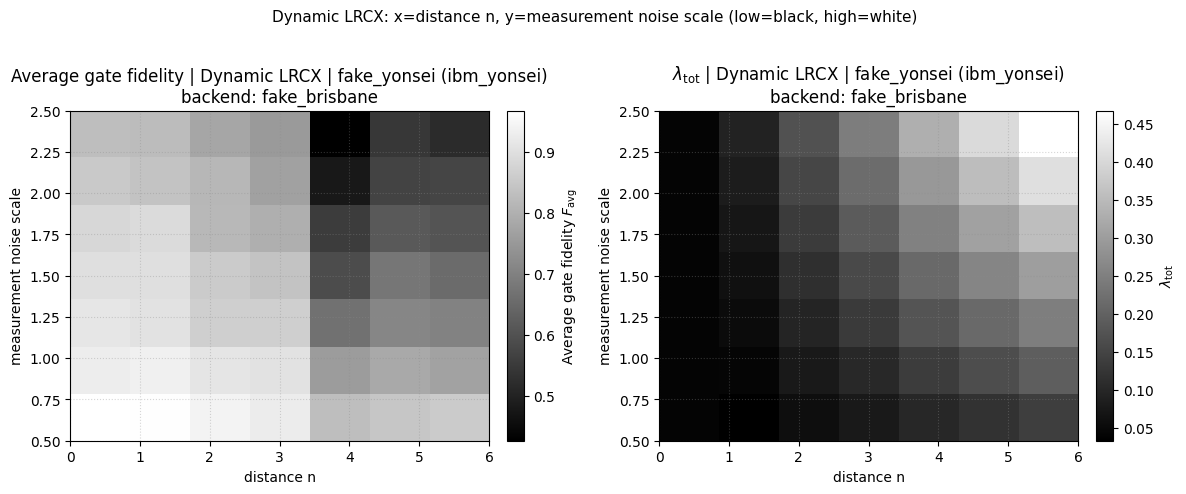

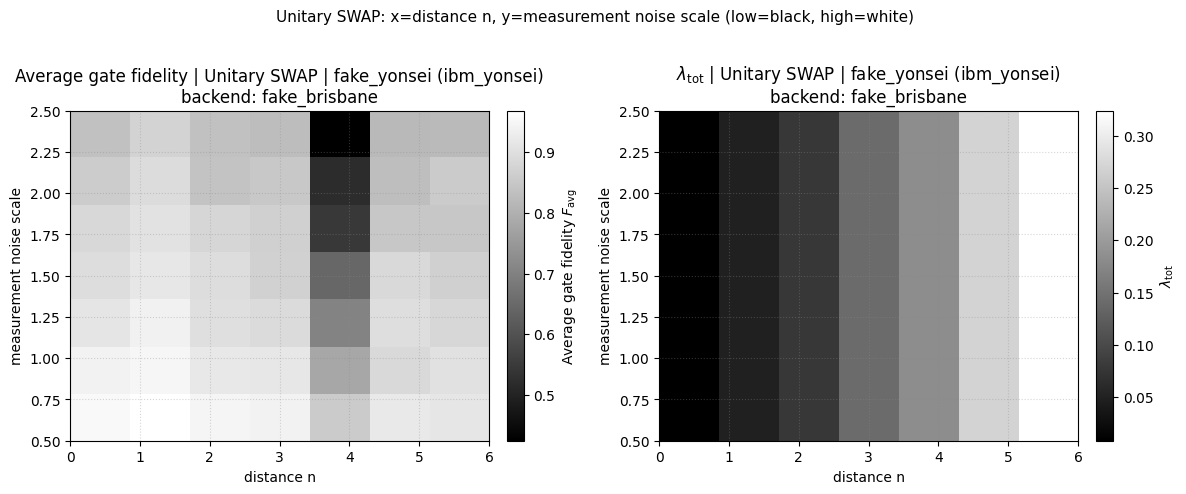

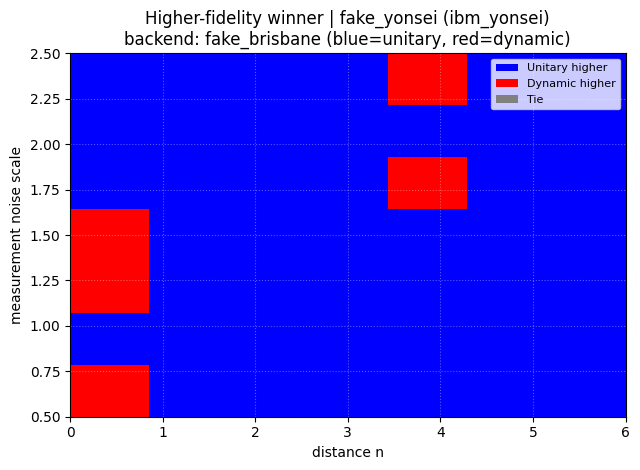

In [47]:
# ------------------------- Distance (n) vs Measurement-noise sweep -------------------------
# Dynamic + Unitary fidelity, lambda_tot, and winner map (blue=unitary, red=dynamic)

DISTANCE_GRID = [2, 4, 6, 8, 10, 12, 14]
MEAS_NOISE_SCALES = np.linspace(0.5, 2.5, 7)
DIST_MEAS_SHOTS = 384


def transpiled_certification_circuits(
    reference_backend,
    distance: int,
    chain: list[int],
    mode: str = "dynamic",
) -> list[QuantumCircuit]:
    circuits = certification_circuits(distance, mode)
    return [transpile_with_bus_layout(c, reference_backend, chain) for c in circuits]


def transpiled_unitary_core(backend, distance: int, chain: list[int]) -> QuantumCircuit:
    core = cnot_unitary_swap(distance)
    return transpile_with_bus_layout(core, backend, chain)


def run_certification_fidelity(
    simulator: AerSimulator,
    reference_backend,
    overrides: HardwareNoiseOverrides,
    isa_circuits: list[QuantumCircuit],
    t1_us: float,
    t2_us: float,
) -> float:
    noise_model = build_sweep_noise_model(reference_backend, overrides, t1_us, t2_us)
    simulator.set_options(noise_model=noise_model)

    counts = []
    for circuit in isa_circuits:
        result = simulator.run(circuit, shots=SWEEP_SHOTS).result()
        counts.append(result.get_counts())

    return compute_fidelity(counts[0], counts[1], counts[2])


run_dynamic_fidelity = run_certification_fidelity


def sweep_distance_measurement_heatmaps(
    display_name: str,
    reference_backend,
    base_overrides: HardwareNoiseOverrides,
    distance_grid: list[int],
    meas_scales: np.ndarray,
):
    fidelity_dyn = np.zeros((len(meas_scales), len(distance_grid)))
    fidelity_uni = np.zeros_like(fidelity_dyn)
    lambda_dyn = np.zeros_like(fidelity_dyn)
    lambda_uni = np.zeros_like(fidelity_dyn)

    cached = {}
    for distance in distance_grid:
        n_logical = distance + 2
        topology_key = (
            "2D square (ibm_miami)"
            if "miami" in display_name
            else "heavy-hex (ibm_yonsei)"
        )
        chain = assign_chain_for_topology(topology_key, reference_backend, n_logical)
        isa_dyn = transpiled_dynamic_core(reference_backend, distance, chain)
        isa_uni = transpiled_unitary_core(reference_backend, distance, chain)
        isa_cert_dyn = transpiled_certification_circuits(
            reference_backend, distance, chain, mode="dynamic"
        )
        isa_cert_uni = transpiled_certification_circuits(
            reference_backend, distance, chain, mode="unitary"
        )
        resources_dyn = error_budget_resources(isa_dyn, reference_backend, distance)
        resources_uni = error_budget_resources(isa_uni, reference_backend, distance)
        summary = summarize_backend_t1_t2(reference_backend, chain)

        cached[distance] = {
            "chain": chain,
            "isa_cert_dyn": isa_cert_dyn,
            "isa_cert_uni": isa_cert_uni,
            "resources_dyn": resources_dyn,
            "resources_uni": resources_uni,
            "t1_us": summary["median_t1_us"],
            "t2_us": summary["median_t2_us"],
            "base_readout": median_readout_error(reference_backend, chain),
        }

    simulator = make_sweep_simulator(reference_backend)
    n_points = len(distance_grid) * len(meas_scales)

    print(f"\n{display_name} | backend={reference_backend.name}")
    print(f"  grid: distance={distance_grid}, meas_scale={np.round(meas_scales, 3).tolist()}")

    for i, meas_scale in enumerate(meas_scales):
        for j, distance in enumerate(distance_grid):
            cfg = cached[distance]
            sweep_overrides = HardwareNoiseOverrides(
                t1_us=cfg["t1_us"],
                t2_us=cfg["t2_us"],
                gate_error_scale=base_overrides.gate_error_scale,
                readout_error_scale=float(meas_scale),
                reset_error_rate=base_overrides.reset_error_rate,
                include_thermal_relaxation=base_overrides.include_thermal_relaxation,
                include_gate_depolarizing=base_overrides.include_gate_depolarizing,
                include_readout_error=base_overrides.include_readout_error,
            )

            fidelity_dyn[i, j] = run_certification_fidelity(
                simulator,
                reference_backend,
                sweep_overrides,
                cfg["isa_cert_dyn"],
                cfg["t1_us"],
                cfg["t2_us"],
            )
            fidelity_uni[i, j] = run_certification_fidelity(
                simulator,
                reference_backend,
                sweep_overrides,
                cfg["isa_cert_uni"],
                cfg["t1_us"],
                cfg["t2_us"],
            )

            budget_params = build_budget_params(
                reference_backend,
                sweep_overrides,
                cfg["t1_us"],
                cfg["t2_us"],
                cfg["chain"],
            )
            lambda_dyn[i, j] = compute_lambda_total(cfg["resources_dyn"], budget_params)
            lambda_uni[i, j] = compute_lambda_total(cfg["resources_uni"], budget_params)

            point = i * len(distance_grid) + j + 1
            if point % max(1, n_points // 6) == 0 or point == n_points:
                ro = cfg["base_readout"] * meas_scale
                print(
                    f"  progress {point}/{n_points} | n={distance}, readout~{ro:.4f}, "
                    f"F_dyn={fidelity_dyn[i, j]:.3f}, F_uni={fidelity_uni[i, j]:.3f}"
                )

        gc.collect()

    meta = {
        "backend_name": reference_backend.name,
        "display_name": display_name,
        "distance_grid": distance_grid,
        "meas_scales": meas_scales,
    }
    return fidelity_dyn, fidelity_uni, lambda_dyn, lambda_uni, meta


def plot_distance_measurement_heatmaps(
    fidelity_map: np.ndarray,
    lambda_map: np.ndarray,
    meta: dict,
    *,
    variant: str = "Dynamic LRCX",
) -> None:
    distance_grid = meta["distance_grid"]
    meas_scales = meta["meas_scales"]
    extent = [distance_grid[0], distance_grid[-1], meas_scales[0], meas_scales[-1]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    panels = [
        (fidelity_map, "Average gate fidelity", r"Average gate fidelity $F_{\mathrm{avg}}$"),
        (lambda_map, r"$\lambda_{\mathrm{tot}}$", r"$\lambda_{\mathrm{tot}}$"),
    ]

    for ax, (data, title, cbar_label) in zip(axes, panels):
        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap="gray",
            vmin=float(np.min(data)),
            vmax=float(np.max(data)),
        )
        ax.set_xlabel("distance n")
        ax.set_ylabel("measurement noise scale")
        ax.set_title(
            f"{title} | {variant} | {meta['display_name']}\nbackend: {meta['backend_name']}"
        )
        ax.grid(True, color="0.55", alpha=0.35, linestyle=":")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    fig.suptitle(
        f"{variant}: x=distance n, y=measurement noise scale (low=black, high=white)",
        y=1.02,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def plot_fidelity_winner_heatmap(
    fidelity_dyn: np.ndarray,
    fidelity_uni: np.ndarray,
    meta: dict,
) -> None:
    """Blue = unitary higher fidelity, red = dynamic higher fidelity."""
    from matplotlib.patches import Patch

    distance_grid = meta["distance_grid"]
    meas_scales = meta["meas_scales"]
    extent = [distance_grid[0], distance_grid[-1], meas_scales[0], meas_scales[-1]]

    rgb = np.zeros((*fidelity_dyn.shape, 3), dtype=float)
    dyn_wins = fidelity_dyn > fidelity_uni
    uni_wins = fidelity_uni > fidelity_dyn
    ties = ~(dyn_wins | uni_wins)

    rgb[dyn_wins] = (1.0, 0.0, 0.0)
    rgb[uni_wins] = (0.0, 0.0, 1.0)
    rgb[ties] = (0.55, 0.55, 0.55)

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.imshow(rgb, origin="lower", aspect="auto", extent=extent)
    ax.set_xlabel("distance n")
    ax.set_ylabel("measurement noise scale")
    ax.set_title(
        f"Higher-fidelity winner | {meta['display_name']}\n"
        f"backend: {meta['backend_name']} (blue=unitary, red=dynamic)"
    )
    ax.grid(True, color="white", alpha=0.35, linestyle=":")
    ax.legend(
        handles=[
            Patch(facecolor="blue", label="Unitary higher"),
            Patch(facecolor="red", label="Dynamic higher"),
            Patch(facecolor="gray", label="Tie"),
        ],
        loc="upper right",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()


for display_name, ref_backend, base_overrides in BACKEND_SWEEP_CONFIGS:
    f_dyn, f_uni, l_dyn, l_uni, meta = sweep_distance_measurement_heatmaps(
        display_name,
        ref_backend,
        base_overrides,
        DISTANCE_GRID,
        MEAS_NOISE_SCALES,
    )
    plot_distance_measurement_heatmaps(f_dyn, l_dyn, meta, variant="Dynamic LRCX")
    plot_distance_measurement_heatmaps(f_uni, l_uni, meta, variant="Unitary SWAP")
    plot_fidelity_winner_heatmap(f_dyn, f_uni, meta)


### Step 3.4 — $\lambda_{\mathrm{CNOT}}$ vs $\lambda_{\mathrm{meas}}$ sweep

Same comparison as Step 3.3 (dynamic vs unitary fidelity + $\lambda_{\mathrm{tot}}$ + winner map), swept over **distance** $n \in \{2,4,6,8,10,12,14\}$ with:

- **x-axis:** $\lambda_{\mathrm{CNOT}}$ (Lindblad-style gate rate)
- **y-axis:** $\lambda_{\mathrm{meas}}$ (Lindblad-style measurement rate)

Grids are centered on each backend's calibrated budget parameters; $\lambda_{\mathrm{idle}}$ is held fixed from T1/T2.



λ_CNOT × λ_meas sweep at distance n=2

fake_miami (ibm_miami) | backend=fake_miami | distance n=2
  resources (dynamic): t_idle=2.32, N_CNOT=3, N_meas=2
  resources (unitary): t_idle=2.09, N_CNOT=9, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.00668, 0.01893, 0.03117, 0.04342, 0.05567, 0.06792, 0.08016]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01893, F_dyn=0.930, F_uni=0.958
  progress 16/49 | λ_CNOT=0.00211, λ_meas=0.03117, F_dyn=0.882, F_uni=0.935
  progress 24/49 | λ_CNOT=0.00348, λ_meas=0.04342, F_dyn=0.834, F_uni=0.901
  progress 32/49 | λ_CNOT=0.00485, λ_meas=0.05567, F_dyn=0.801, F_uni=0.873
  progress 40/49 | λ_CNOT=0.00621, λ_meas=0.06792, F_dyn=0.790, F_uni=0.841
  progress 48/49 | λ_CNOT=0.00758, λ_meas=0.08016, F_dyn=0.732, F_uni=0.831
  progress 49/49 | λ_CNOT=0.00895, λ_meas=0.08016, F_dyn=0.757, F_uni=0.841


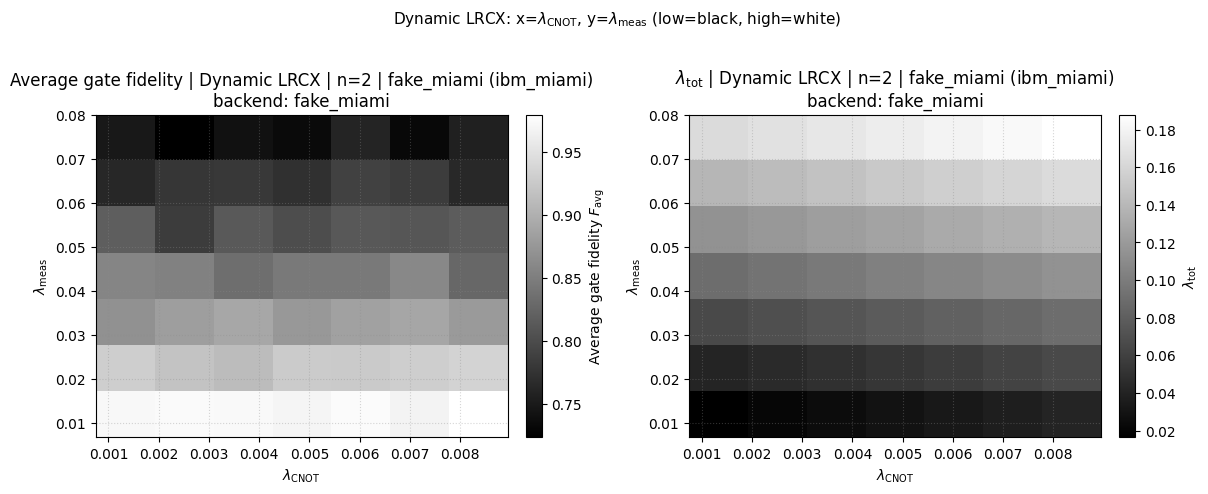

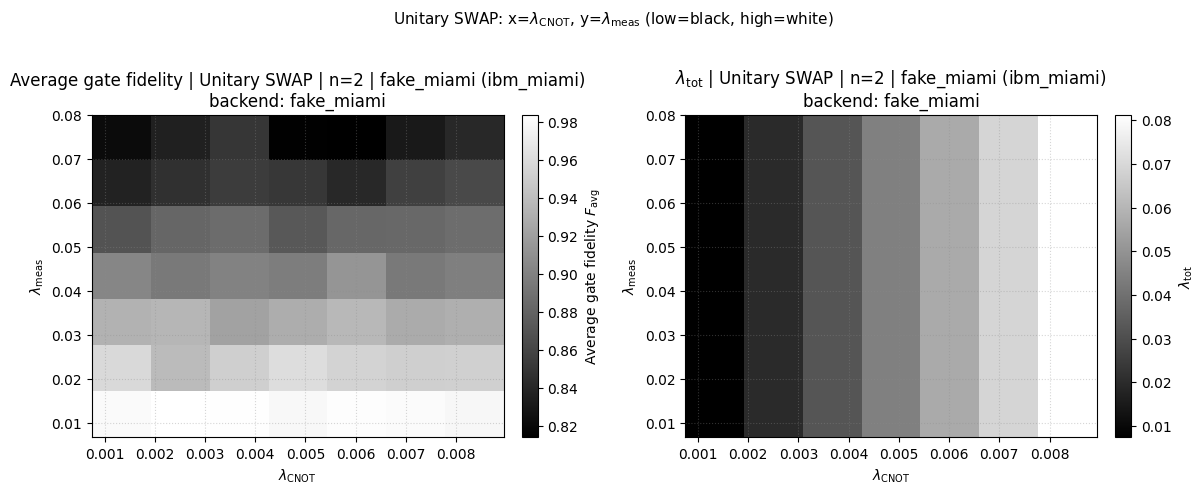

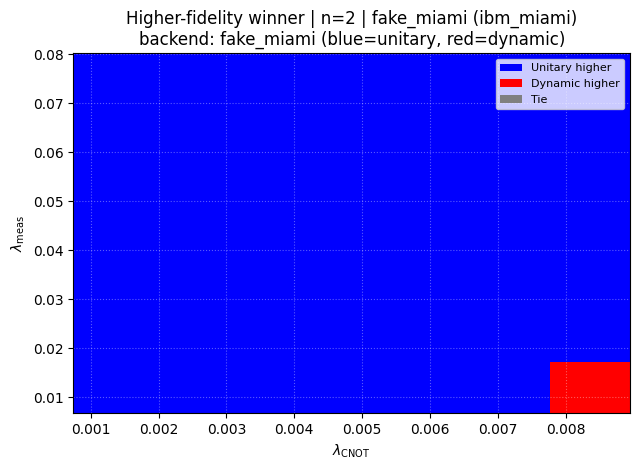


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance n=2
  resources (dynamic): t_idle=2.18, N_CNOT=3, N_meas=2
  resources (unitary): t_idle=2.64, N_CNOT=9, N_meas=0
  lambda_CNOT grid: [0.00194, 0.00549, 0.00904, 0.01259, 0.01614, 0.0197, 0.02325]
  lambda_meas grid: [0.01057, 0.02994, 0.04931, 0.06868, 0.08805, 0.10742, 0.12679]
  progress 8/49 | λ_CNOT=0.00194, λ_meas=0.02994, F_dyn=0.893, F_uni=0.925
  progress 16/49 | λ_CNOT=0.00549, λ_meas=0.04931, F_dyn=0.848, F_uni=0.868
  progress 24/49 | λ_CNOT=0.00904, λ_meas=0.06868, F_dyn=0.797, F_uni=0.832
  progress 32/49 | λ_CNOT=0.01259, λ_meas=0.08805, F_dyn=0.740, F_uni=0.815
  progress 40/49 | λ_CNOT=0.01614, λ_meas=0.10742, F_dyn=0.688, F_uni=0.763
  progress 48/49 | λ_CNOT=0.01970, λ_meas=0.12679, F_dyn=0.670, F_uni=0.749
  progress 49/49 | λ_CNOT=0.02325, λ_meas=0.12679, F_dyn=0.673, F_uni=0.735


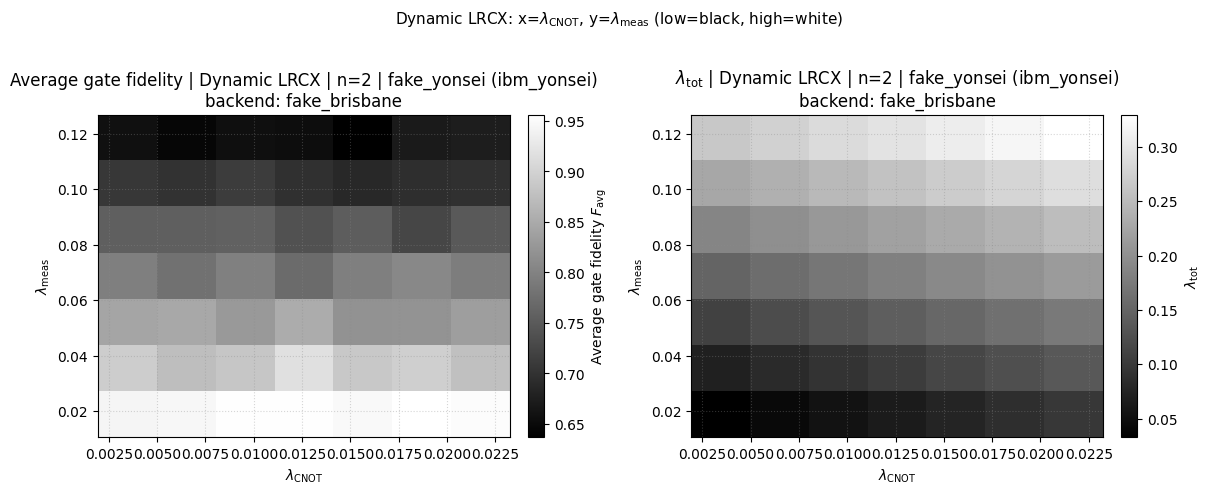

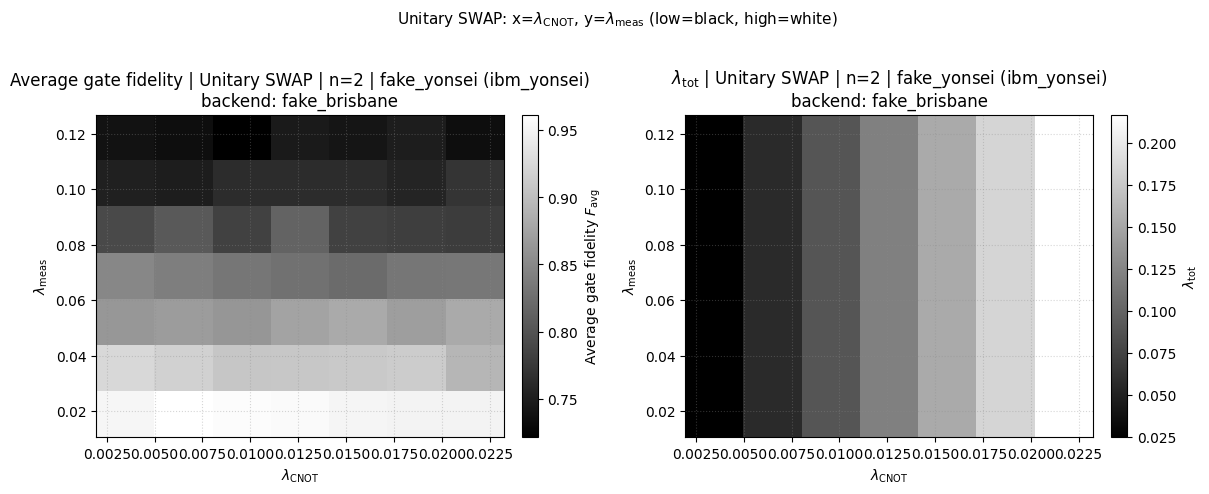

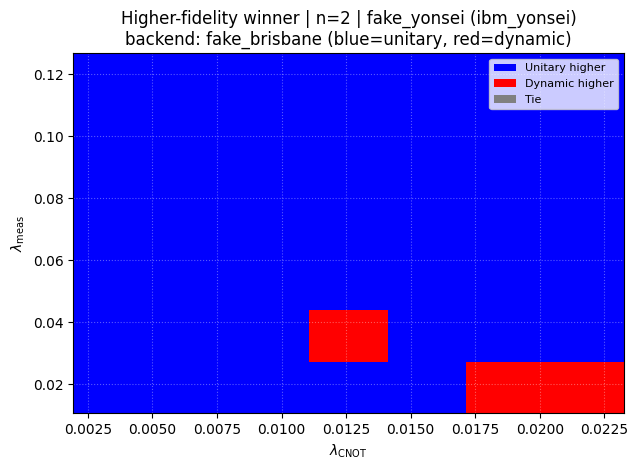


λ_CNOT × λ_meas sweep at distance n=4

fake_miami (ibm_miami) | backend=fake_miami | distance n=4
  resources (dynamic): t_idle=2.32, N_CNOT=5, N_meas=4
  resources (unitary): t_idle=17.39, N_CNOT=17, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.00628, 0.0178, 0.02931, 0.04083, 0.05234, 0.06386, 0.07537]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01780, F_dyn=0.909, F_uni=0.959
  progress 16/49 | λ_CNOT=0.00211, λ_meas=0.02931, F_dyn=0.849, F_uni=0.926
  progress 24/49 | λ_CNOT=0.00348, λ_meas=0.04083, F_dyn=0.799, F_uni=0.896
  progress 32/49 | λ_CNOT=0.00485, λ_meas=0.05234, F_dyn=0.752, F_uni=0.873
  progress 40/49 | λ_CNOT=0.00621, λ_meas=0.06386, F_dyn=0.735, F_uni=0.858
  progress 48/49 | λ_CNOT=0.00758, λ_meas=0.07537, F_dyn=0.704, F_uni=0.820
  progress 49/49 | λ_CNOT=0.00895, λ_meas=0.07537, F_dyn=0.705, F_uni=0.835


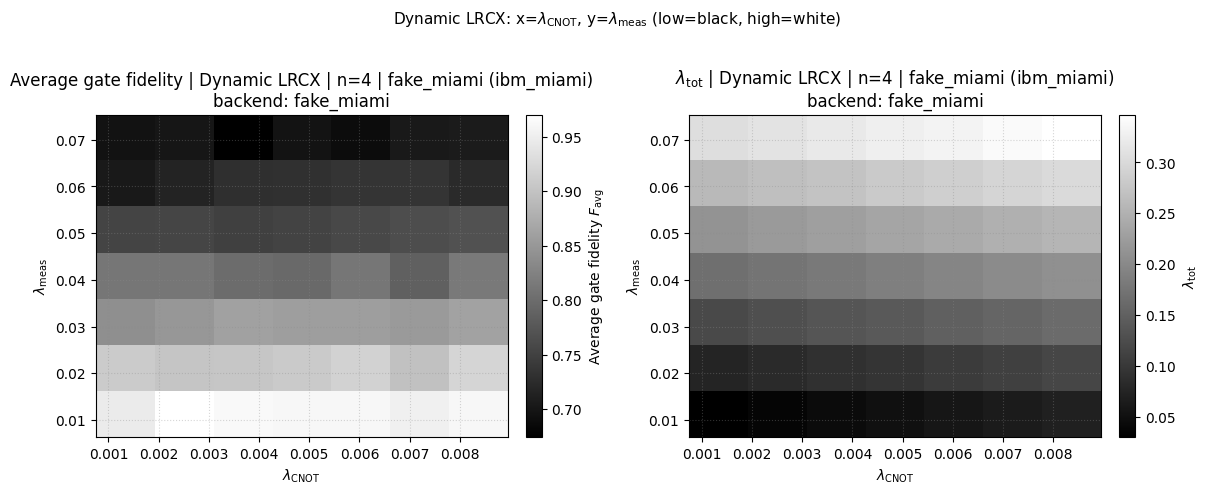

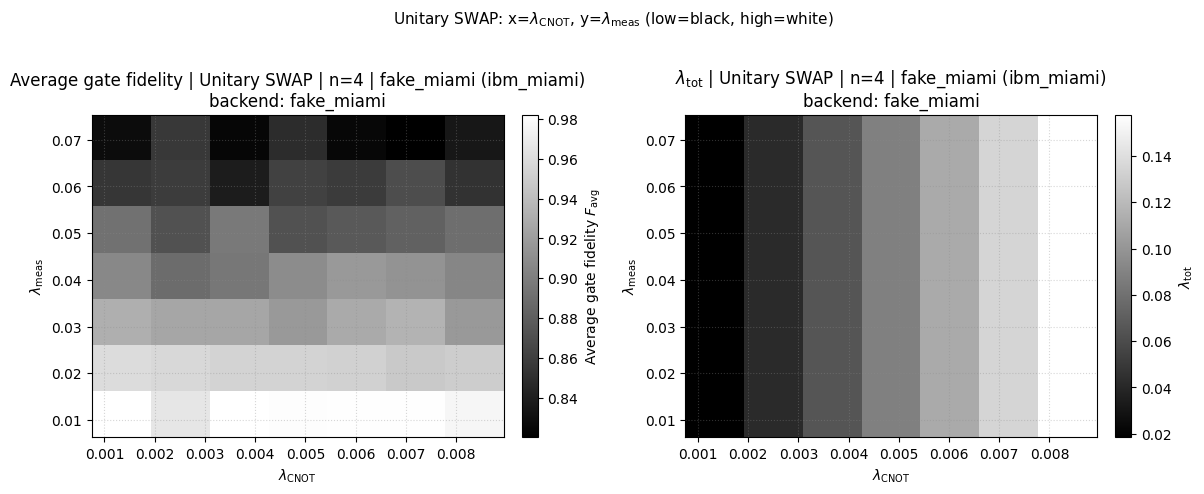

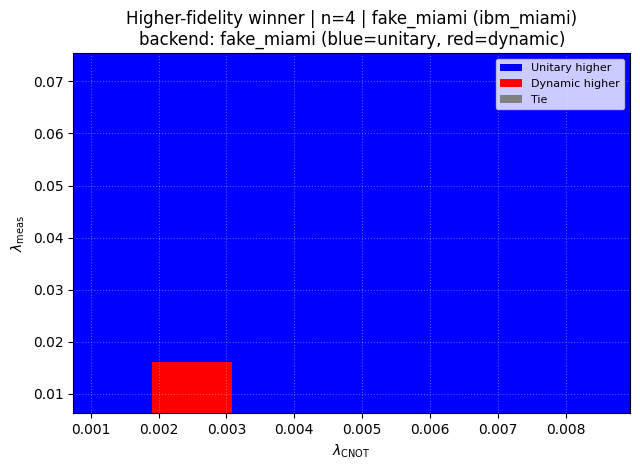


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance n=4
  resources (dynamic): t_idle=2.18, N_CNOT=5, N_meas=4
  resources (unitary): t_idle=18.18, N_CNOT=17, N_meas=0
  lambda_CNOT grid: [0.00194, 0.00549, 0.00904, 0.01259, 0.01614, 0.0197, 0.02325]
  lambda_meas grid: [0.01057, 0.02994, 0.04931, 0.06868, 0.08805, 0.10742, 0.12679]
  progress 8/49 | λ_CNOT=0.00194, λ_meas=0.02994, F_dyn=0.680, F_uni=0.702
  progress 16/49 | λ_CNOT=0.00549, λ_meas=0.04931, F_dyn=0.546, F_uni=0.601
  progress 24/49 | λ_CNOT=0.00904, λ_meas=0.06868, F_dyn=0.430, F_uni=0.450
  progress 32/49 | λ_CNOT=0.01259, λ_meas=0.08805, F_dyn=0.359, F_uni=0.346
  progress 40/49 | λ_CNOT=0.01614, λ_meas=0.10742, F_dyn=0.301, F_uni=0.225
  progress 48/49 | λ_CNOT=0.01970, λ_meas=0.12679, F_dyn=0.273, F_uni=0.157
  progress 49/49 | λ_CNOT=0.02325, λ_meas=0.12679, F_dyn=0.246, F_uni=0.154


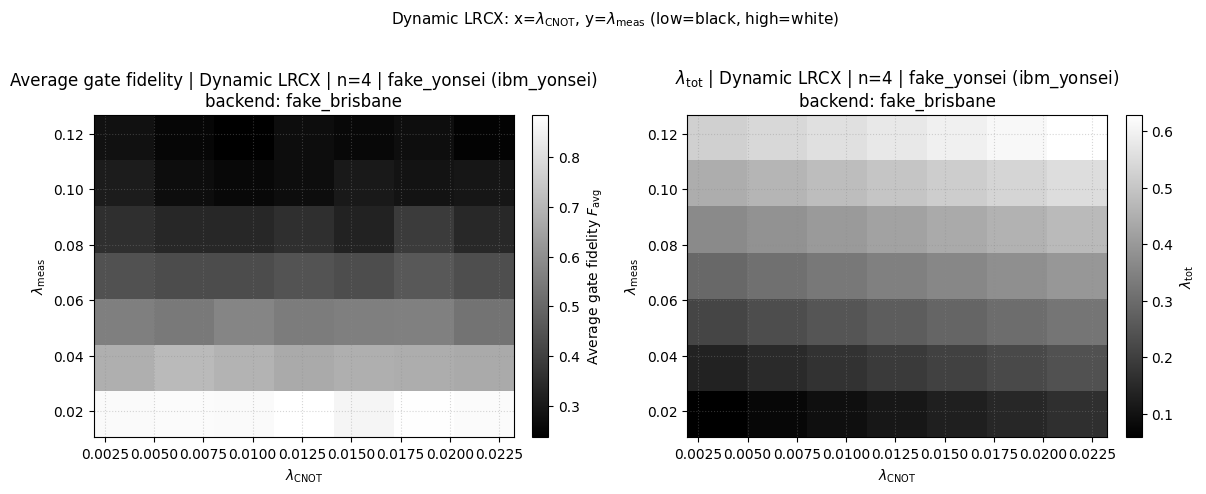

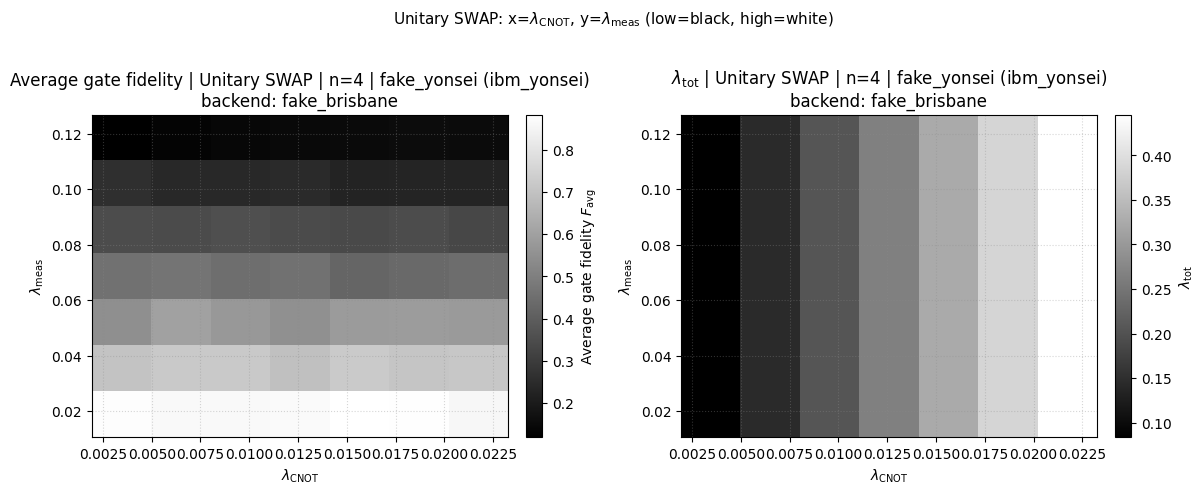

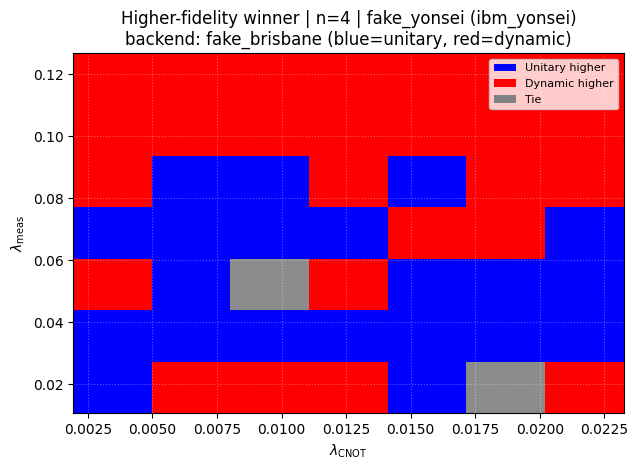


λ_CNOT × λ_meas sweep at distance n=6

fake_miami (ibm_miami) | backend=fake_miami | distance n=6
  resources (dynamic): t_idle=2.32, N_CNOT=7, N_meas=6
  resources (unitary): t_idle=45.22, N_CNOT=25, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.0063, 0.01786, 0.02942, 0.04098, 0.05254, 0.06409, 0.07565]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01786, F_dyn=0.875, F_uni=0.953
  progress 16/49 | λ_CNOT=0.00211, λ_meas=0.02942, F_dyn=0.801, F_uni=0.907
  progress 24/49 | λ_CNOT=0.00348, λ_meas=0.04098, F_dyn=0.774, F_uni=0.884
  progress 32/49 | λ_CNOT=0.00485, λ_meas=0.05254, F_dyn=0.698, F_uni=0.834
  progress 40/49 | λ_CNOT=0.00621, λ_meas=0.06409, F_dyn=0.667, F_uni=0.811
  progress 48/49 | λ_CNOT=0.00758, λ_meas=0.07565, F_dyn=0.616, F_uni=0.825
  progress 49/49 | λ_CNOT=0.00895, λ_meas=0.07565, F_dyn=0.614, F_uni=0.796


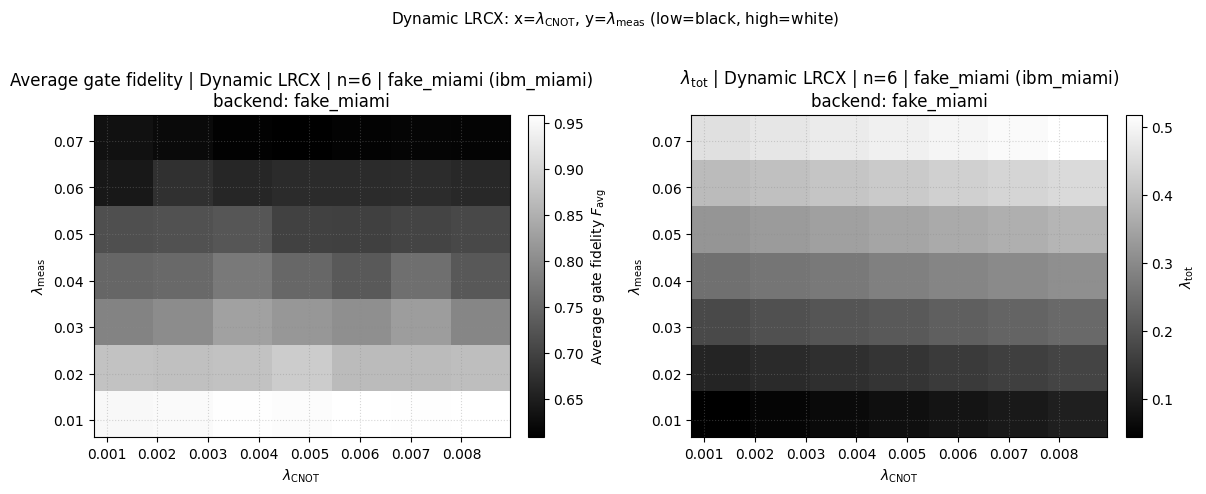

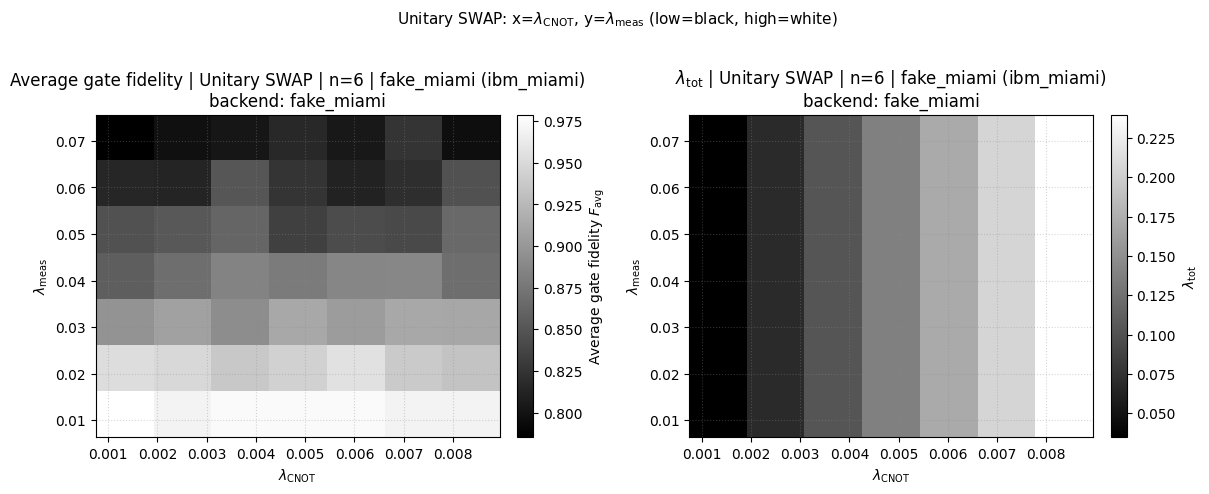

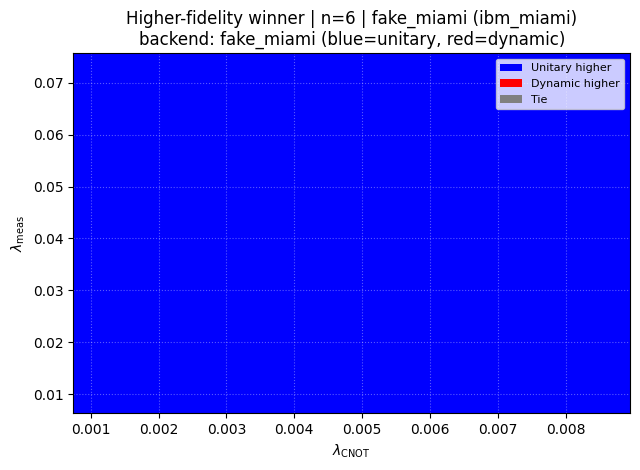


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance n=6
  resources (dynamic): t_idle=2.18, N_CNOT=7, N_meas=6
  resources (unitary): t_idle=46.91, N_CNOT=25, N_meas=0
  lambda_CNOT grid: [0.00194, 0.00549, 0.00904, 0.01259, 0.01614, 0.0197, 0.02325]
  lambda_meas grid: [0.01004, 0.02845, 0.04686, 0.06527, 0.08367, 0.10208, 0.12049]
  progress 8/49 | λ_CNOT=0.00194, λ_meas=0.02845, F_dyn=0.729, F_uni=0.877
  progress 16/49 | λ_CNOT=0.00549, λ_meas=0.04686, F_dyn=0.614, F_uni=0.845
  progress 24/49 | λ_CNOT=0.00904, λ_meas=0.06527, F_dyn=0.537, F_uni=0.840
  progress 32/49 | λ_CNOT=0.01259, λ_meas=0.08367, F_dyn=0.455, F_uni=0.821
  progress 40/49 | λ_CNOT=0.01614, λ_meas=0.10208, F_dyn=0.443, F_uni=0.782
  progress 48/49 | λ_CNOT=0.01970, λ_meas=0.12049, F_dyn=0.438, F_uni=0.755
  progress 49/49 | λ_CNOT=0.02325, λ_meas=0.12049, F_dyn=0.443, F_uni=0.747


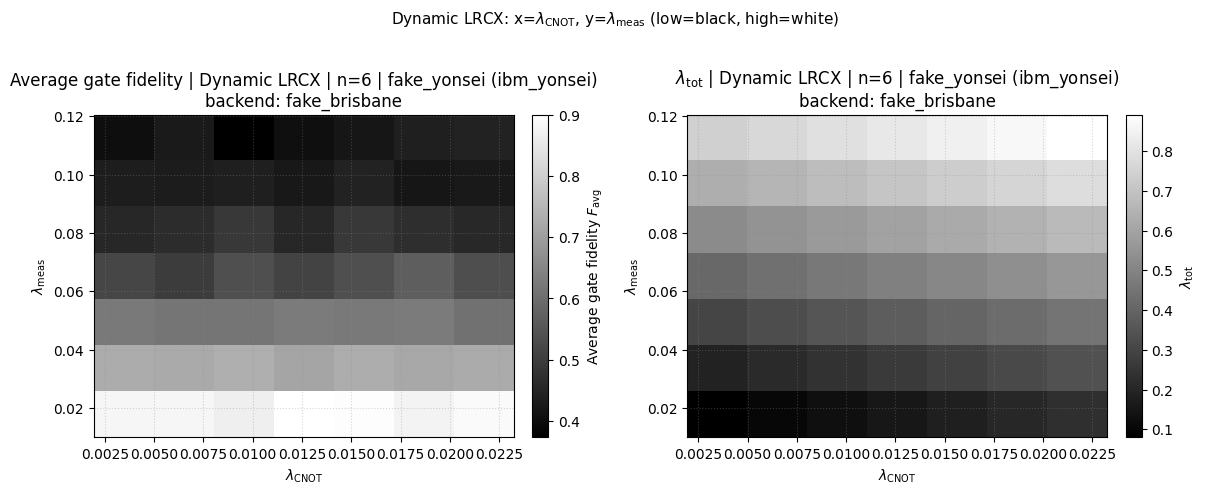

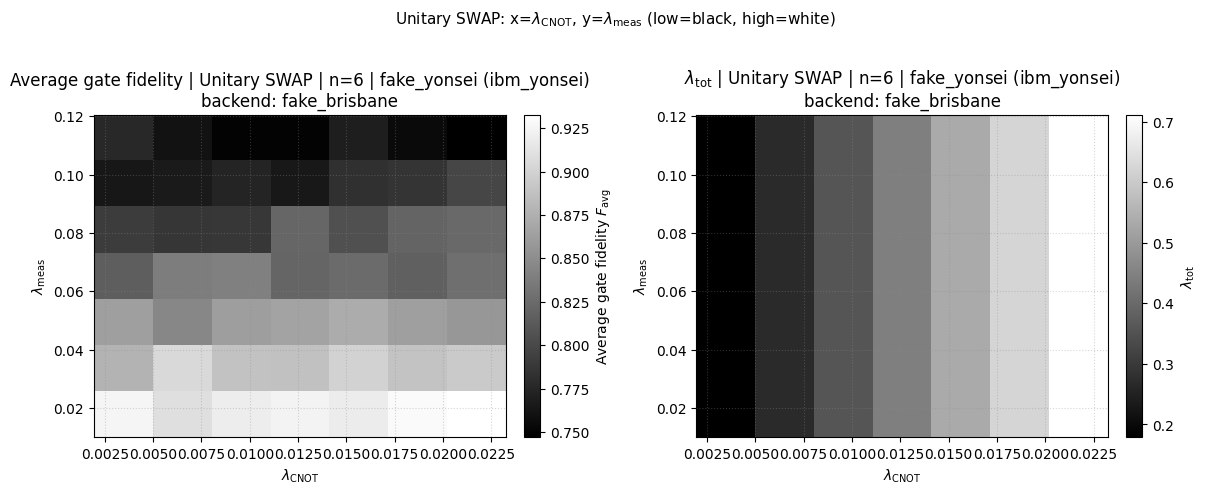

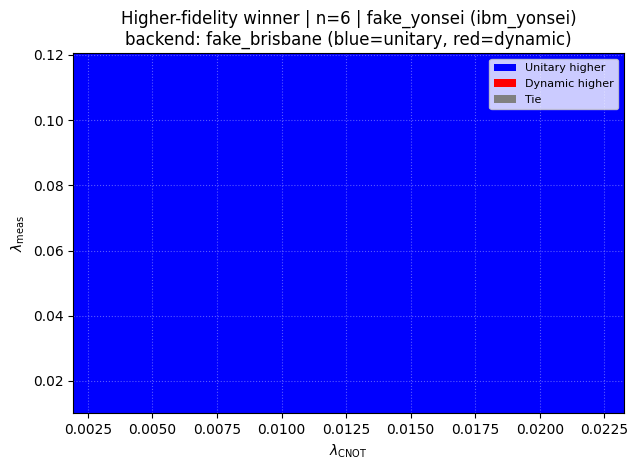


λ_CNOT × λ_meas sweep at distance n=8

fake_miami (ibm_miami) | backend=fake_miami | distance n=8
  resources (dynamic): t_idle=2.32, N_CNOT=9, N_meas=8
  resources (unitary): t_idle=83.25, N_CNOT=33, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.0063, 0.01786, 0.02942, 0.04098, 0.05254, 0.06409, 0.07565]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01786, F_dyn=0.851, F_uni=0.959
  progress 16/49 | λ_CNOT=0.00211, λ_meas=0.02942, F_dyn=0.771, F_uni=0.950
  progress 24/49 | λ_CNOT=0.00348, λ_meas=0.04098, F_dyn=0.723, F_uni=0.899
  progress 32/49 | λ_CNOT=0.00485, λ_meas=0.05254, F_dyn=0.649, F_uni=0.913
  progress 40/49 | λ_CNOT=0.00621, λ_meas=0.06409, F_dyn=0.636, F_uni=0.883
  progress 48/49 | λ_CNOT=0.00758, λ_meas=0.07565, F_dyn=0.591, F_uni=0.866
  progress 49/49 | λ_CNOT=0.00895, λ_meas=0.07565, F_dyn=0.592, F_uni=0.855


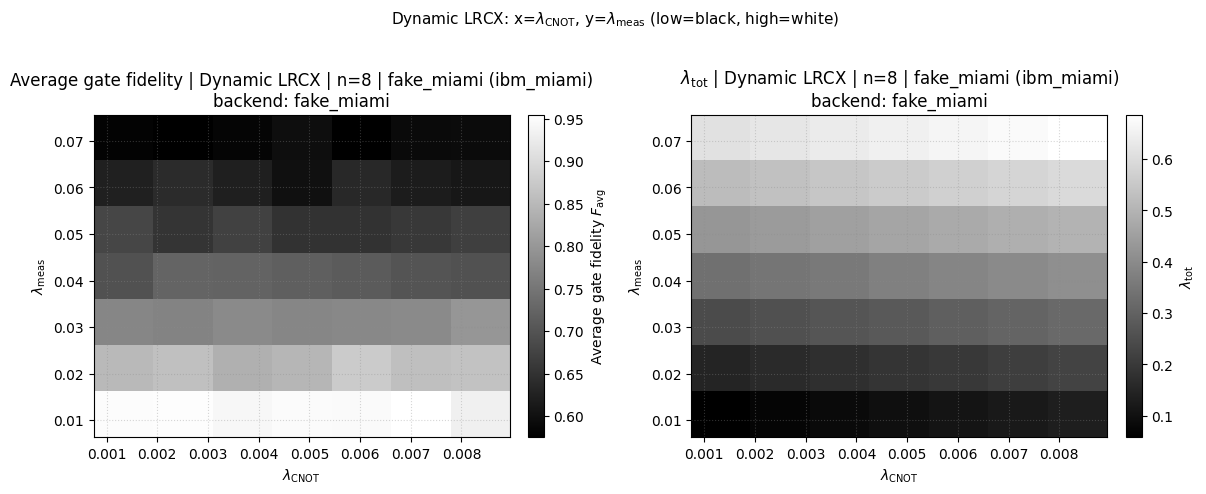

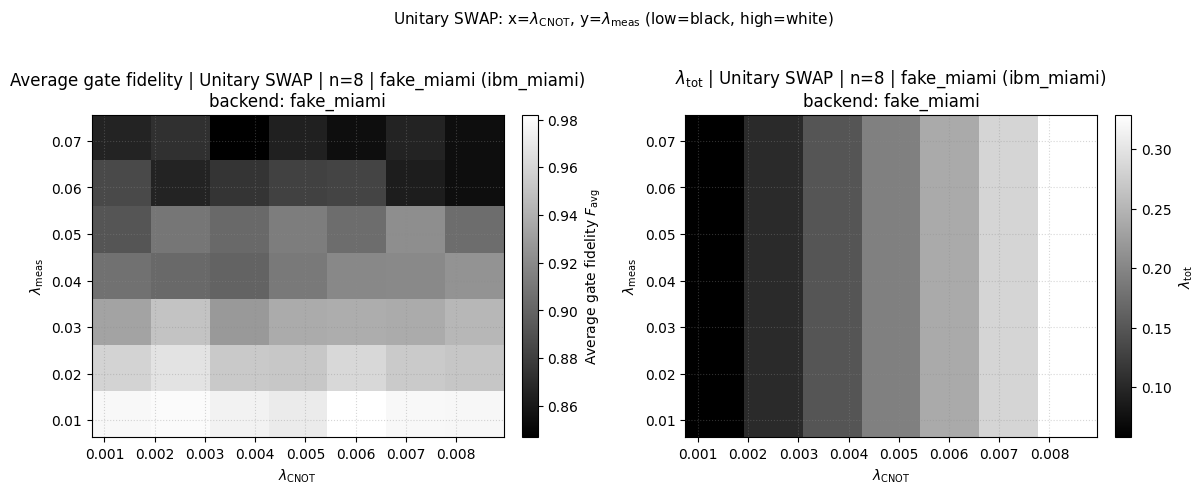

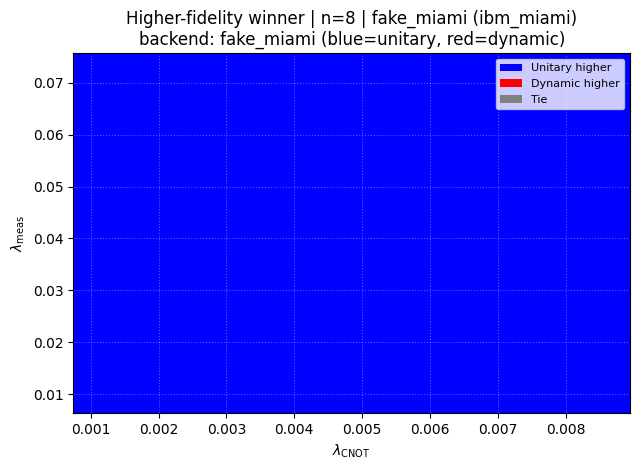


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance n=8
  resources (dynamic): t_idle=2.09, N_CNOT=9, N_meas=8
  resources (unitary): t_idle=87.91, N_CNOT=33, N_meas=0
  lambda_CNOT grid: [0.00194, 0.00549, 0.00904, 0.01259, 0.01614, 0.0197, 0.02325]
  lambda_meas grid: [0.00928, 0.02629, 0.0433, 0.06032, 0.07733, 0.09434, 0.11136]
  progress 8/49 | λ_CNOT=0.00194, λ_meas=0.02629, F_dyn=0.702, F_uni=0.894
  progress 16/49 | λ_CNOT=0.00549, λ_meas=0.04330, F_dyn=0.627, F_uni=0.869
  progress 24/49 | λ_CNOT=0.00904, λ_meas=0.06032, F_dyn=0.540, F_uni=0.851
  progress 32/49 | λ_CNOT=0.01259, λ_meas=0.07733, F_dyn=0.466, F_uni=0.808
  progress 40/49 | λ_CNOT=0.01614, λ_meas=0.09434, F_dyn=0.461, F_uni=0.783
  progress 48/49 | λ_CNOT=0.01970, λ_meas=0.11136, F_dyn=0.399, F_uni=0.780
  progress 49/49 | λ_CNOT=0.02325, λ_meas=0.11136, F_dyn=0.403, F_uni=0.772


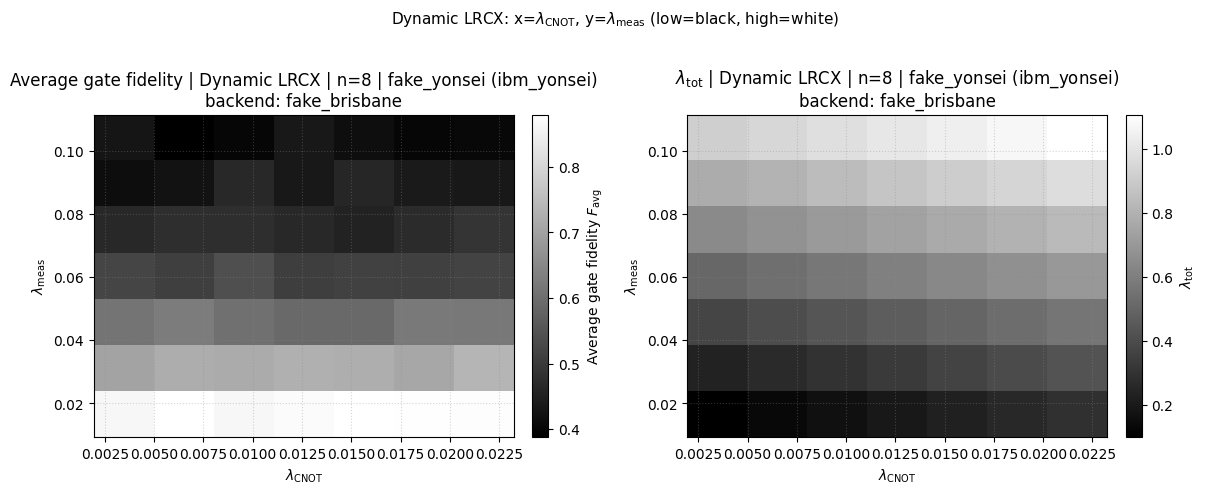

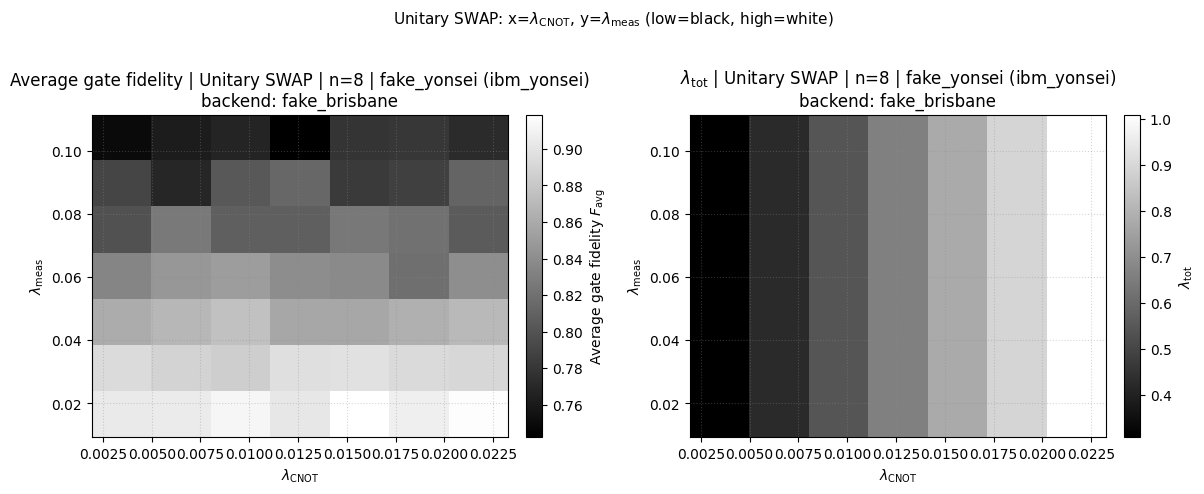

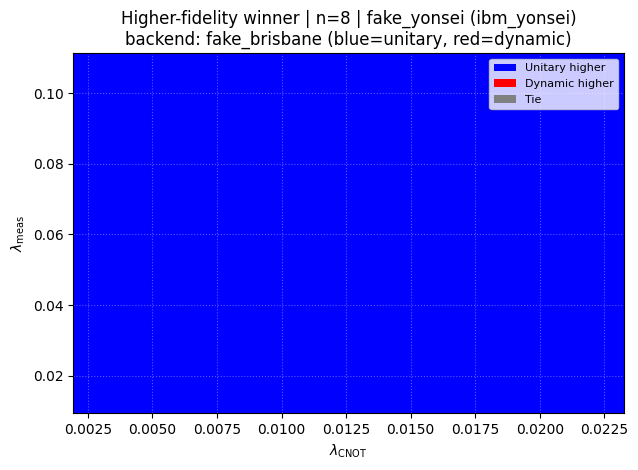


λ_CNOT × λ_meas sweep at distance n=10

fake_miami (ibm_miami) | backend=fake_miami | distance n=10
  resources (dynamic): t_idle=2.32, N_CNOT=11, N_meas=10
  resources (unitary): t_idle=135.07, N_CNOT=41, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.00616, 0.01746, 0.02876, 0.04006, 0.05136, 0.06266, 0.07396]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01746, F_dyn=0.820, F_uni=0.941
  progress 16/49 | λ_CNOT=0.00211, λ_meas=0.02876, F_dyn=0.755, F_uni=0.924
  progress 24/49 | λ_CNOT=0.00348, λ_meas=0.04006, F_dyn=0.676, F_uni=0.905
  progress 32/49 | λ_CNOT=0.00485, λ_meas=0.05136, F_dyn=0.606, F_uni=0.865
  progress 40/49 | λ_CNOT=0.00621, λ_meas=0.06266, F_dyn=0.575, F_uni=0.859
  progress 48/49 | λ_CNOT=0.00758, λ_meas=0.07396, F_dyn=0.562, F_uni=0.805
  progress 49/49 | λ_CNOT=0.00895, λ_meas=0.07396, F_dyn=0.541, F_uni=0.842


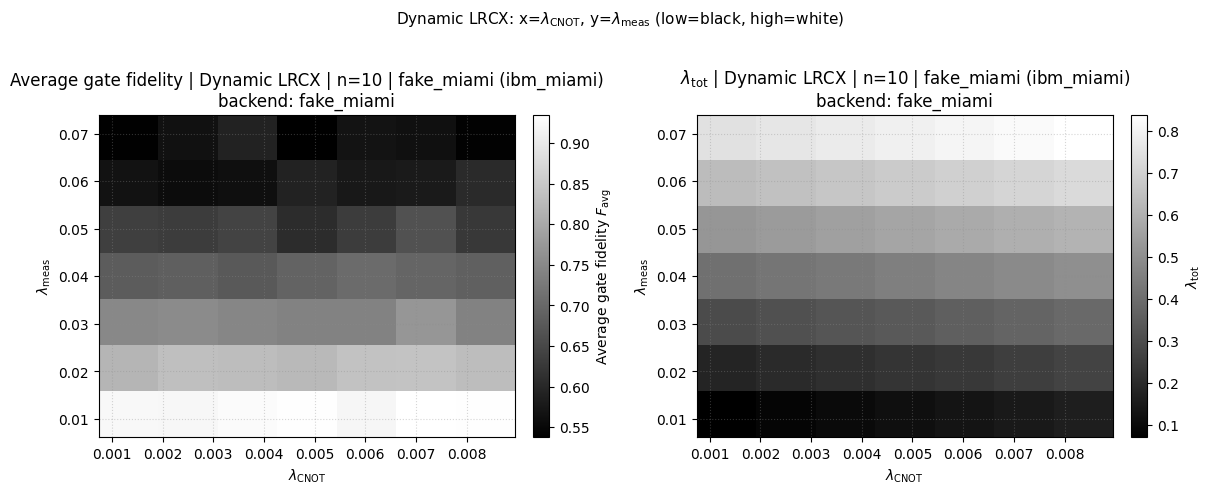

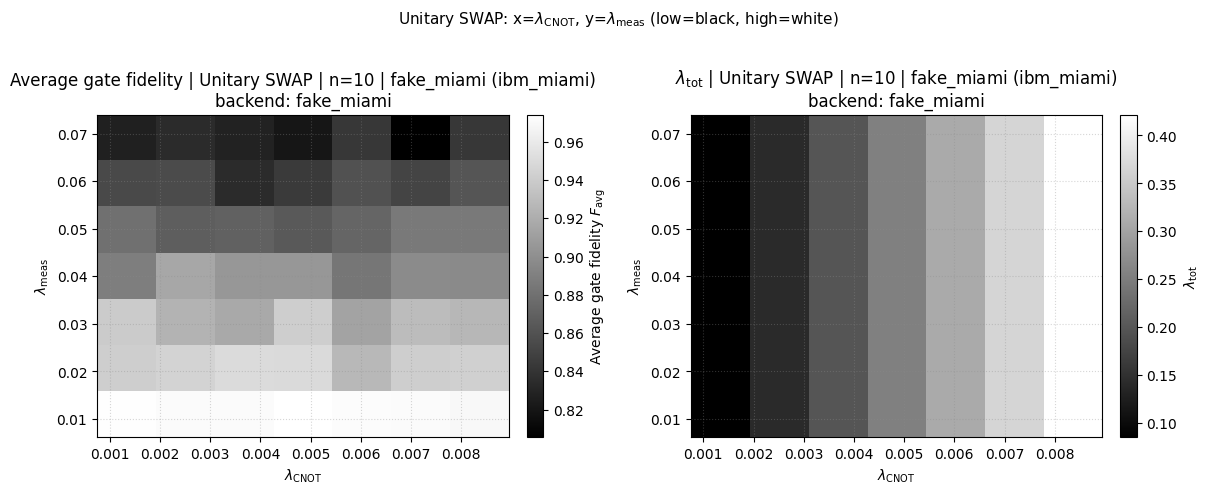

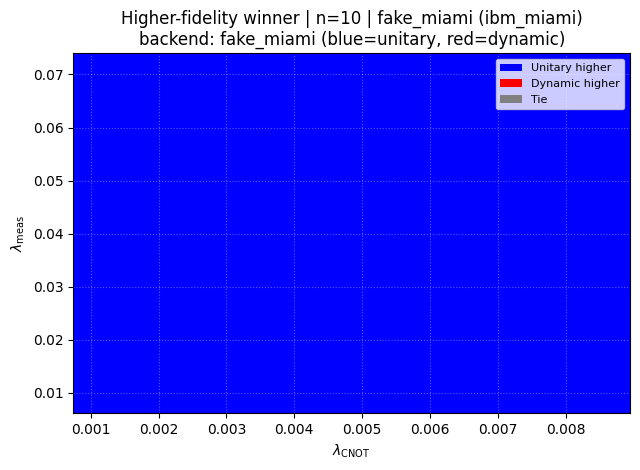


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance n=10
  resources (dynamic): t_idle=2.27, N_CNOT=11, N_meas=10
  resources (unitary): t_idle=143.55, N_CNOT=41, N_meas=0
  lambda_CNOT grid: [0.00194, 0.00549, 0.00904, 0.01259, 0.01614, 0.0197, 0.02325]
  lambda_meas grid: [0.00928, 0.02629, 0.0433, 0.06032, 0.07733, 0.09434, 0.11136]
  progress 8/49 | λ_CNOT=0.00194, λ_meas=0.02629, F_dyn=0.607, F_uni=0.734
  progress 16/49 | λ_CNOT=0.00549, λ_meas=0.04330, F_dyn=0.505, F_uni=0.609
  progress 24/49 | λ_CNOT=0.00904, λ_meas=0.06032, F_dyn=0.448, F_uni=0.491
  progress 32/49 | λ_CNOT=0.01259, λ_meas=0.07733, F_dyn=0.373, F_uni=0.402
  progress 40/49 | λ_CNOT=0.01614, λ_meas=0.09434, F_dyn=0.409, F_uni=0.338
  progress 48/49 | λ_CNOT=0.01970, λ_meas=0.11136, F_dyn=0.420, F_uni=0.263
  progress 49/49 | λ_CNOT=0.02325, λ_meas=0.11136, F_dyn=0.398, F_uni=0.268


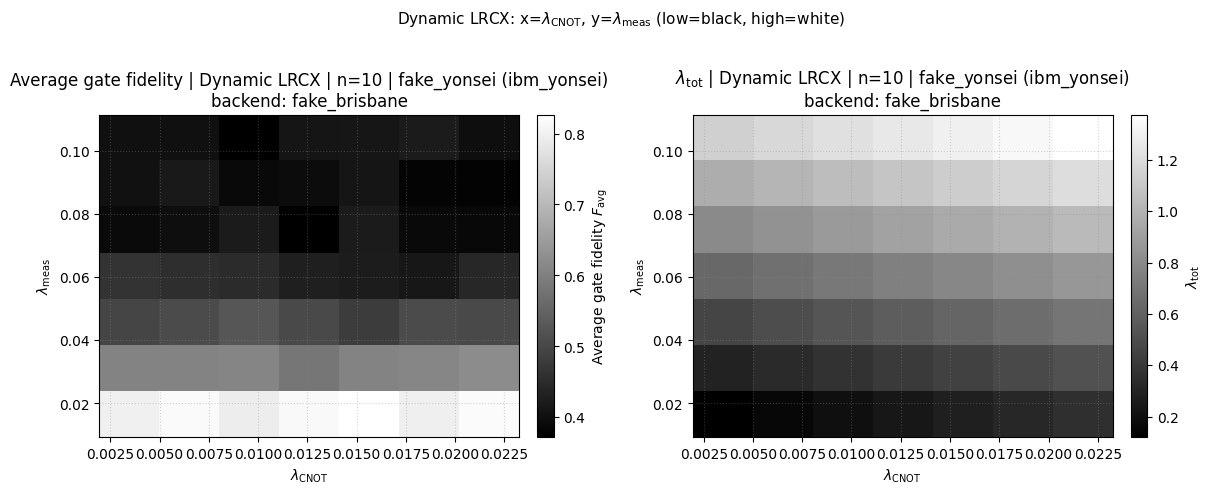

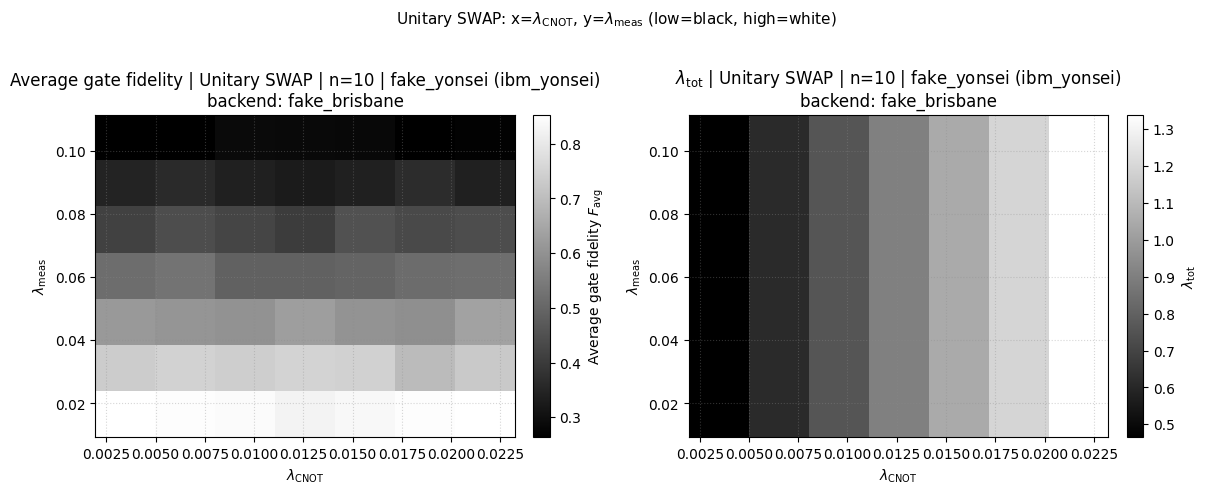

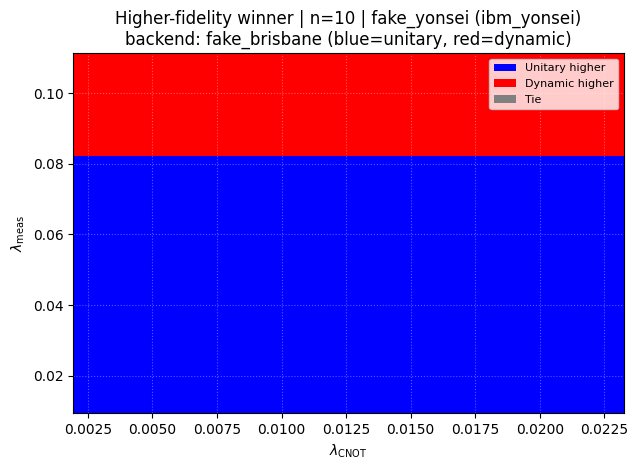


λ_CNOT × λ_meas sweep at distance n=12

fake_miami (ibm_miami) | backend=fake_miami | distance n=12
  resources (dynamic): t_idle=2.32, N_CNOT=13, N_meas=12
  resources (unitary): t_idle=199.42, N_CNOT=49, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.00609, 0.01726, 0.02844, 0.03961, 0.05078, 0.06195, 0.07312]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01726, F_dyn=0.812, F_uni=0.966
  progress 16/49 | λ_CNOT=0.00211, λ_meas=0.02844, F_dyn=0.736, F_uni=0.944
  progress 24/49 | λ_CNOT=0.00348, λ_meas=0.03961, F_dyn=0.666, F_uni=0.915
  progress 32/49 | λ_CNOT=0.00485, λ_meas=0.05078, F_dyn=0.611, F_uni=0.893
  progress 40/49 | λ_CNOT=0.00621, λ_meas=0.06195, F_dyn=0.574, F_uni=0.870
  progress 48/49 | λ_CNOT=0.00758, λ_meas=0.07312, F_dyn=0.524, F_uni=0.863
  progress 49/49 | λ_CNOT=0.00895, λ_meas=0.07312, F_dyn=0.553, F_uni=0.879


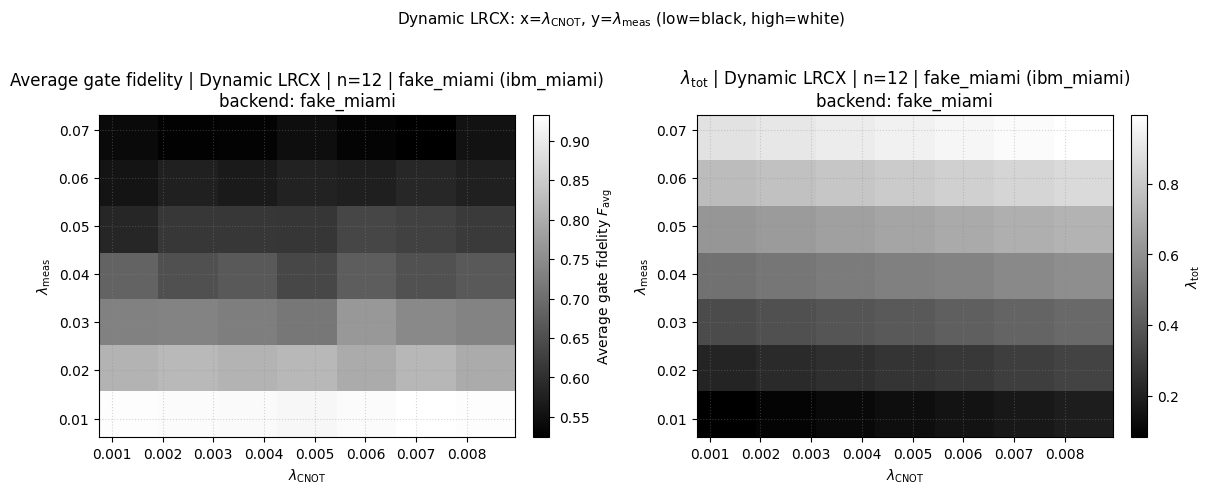

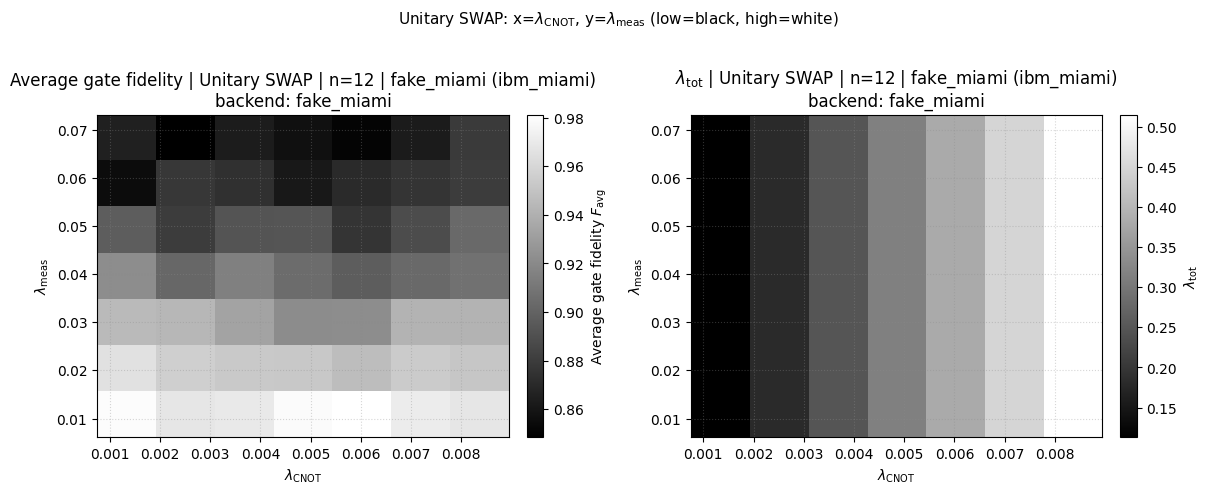

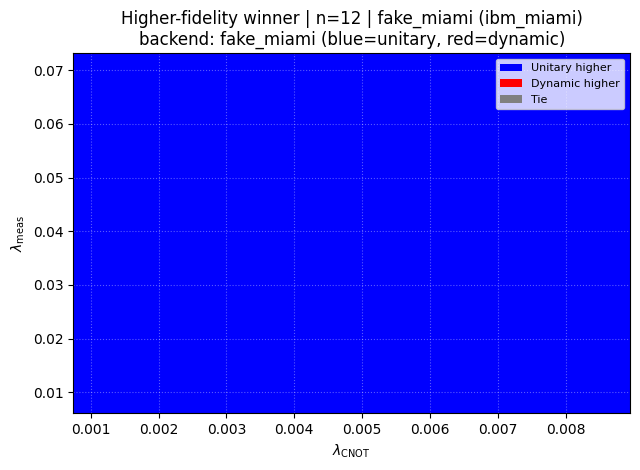


fake_yonsei (ibm_yonsei) | backend=fake_brisbane | distance n=12
  resources (dynamic): t_idle=2.27, N_CNOT=13, N_meas=12
  resources (unitary): t_idle=209.82, N_CNOT=49, N_meas=0
  lambda_CNOT grid: [0.00194, 0.00549, 0.00904, 0.01259, 0.01614, 0.0197, 0.02325]
  lambda_meas grid: [0.00885, 0.02508, 0.04131, 0.05754, 0.07377, 0.09, 0.10623]
  progress 8/49 | λ_CNOT=0.00194, λ_meas=0.02508, F_dyn=0.613, F_uni=0.861
  progress 16/49 | λ_CNOT=0.00549, λ_meas=0.04131, F_dyn=0.516, F_uni=0.795
  progress 24/49 | λ_CNOT=0.00904, λ_meas=0.05754, F_dyn=0.512, F_uni=0.798
  progress 32/49 | λ_CNOT=0.01259, λ_meas=0.07377, F_dyn=0.469, F_uni=0.744
  progress 40/49 | λ_CNOT=0.01614, λ_meas=0.09000, F_dyn=0.447, F_uni=0.724
  progress 48/49 | λ_CNOT=0.01970, λ_meas=0.10623, F_dyn=0.462, F_uni=0.710
  progress 49/49 | λ_CNOT=0.02325, λ_meas=0.10623, F_dyn=0.455, F_uni=0.701


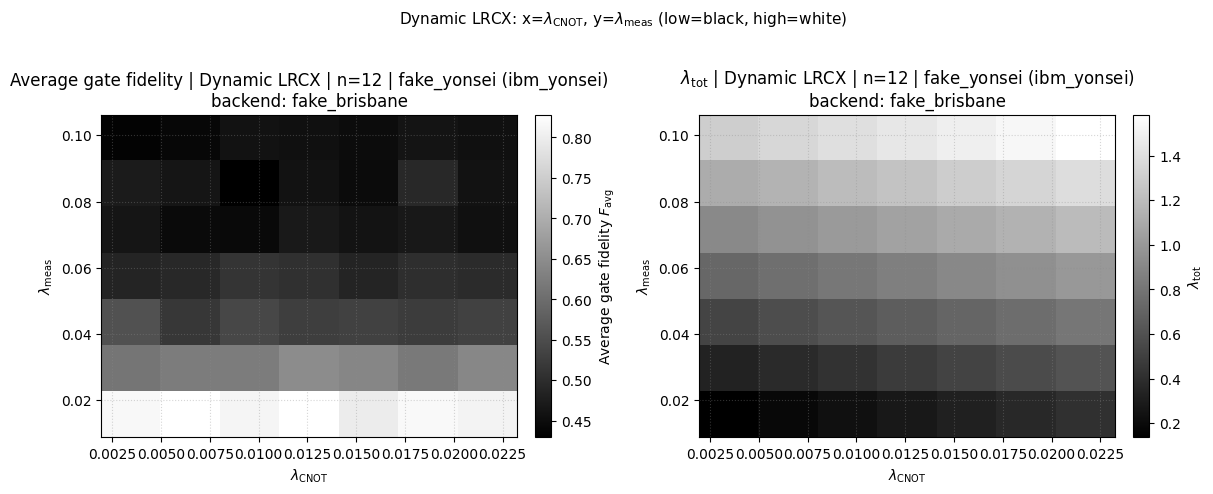

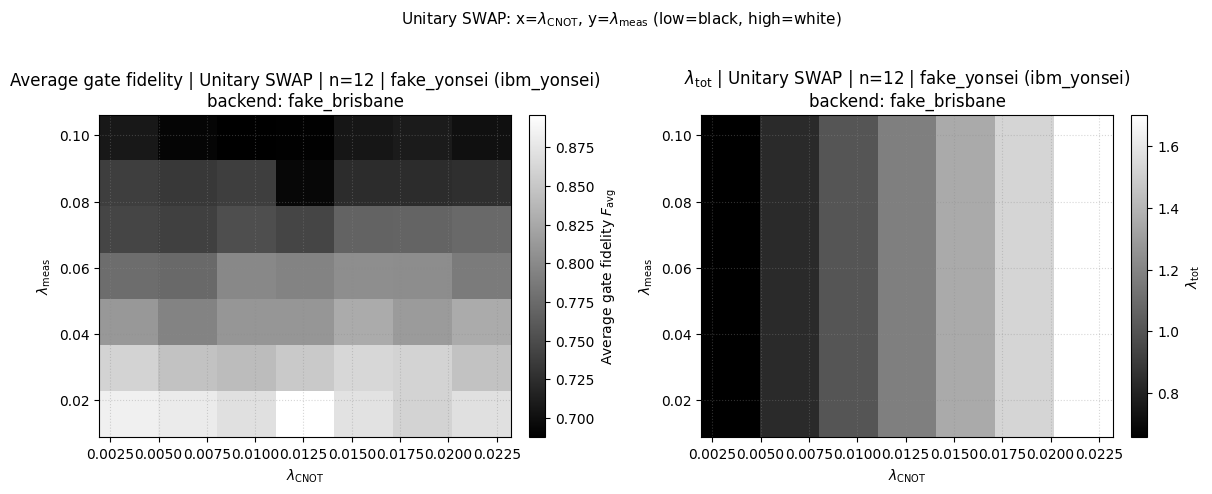

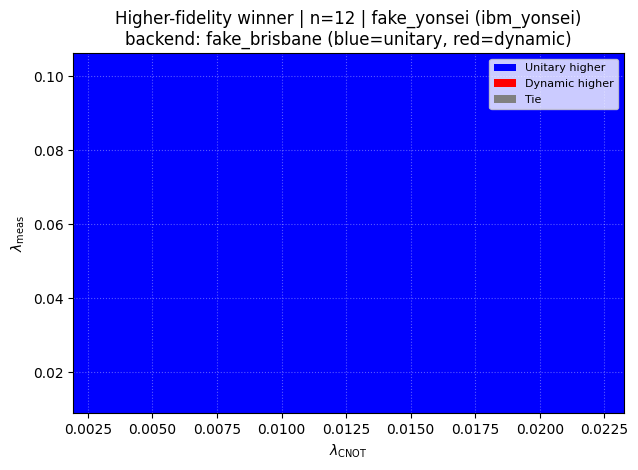


λ_CNOT × λ_meas sweep at distance n=14

fake_miami (ibm_miami) | backend=fake_miami | distance n=14
  resources (dynamic): t_idle=2.61, N_CNOT=15, N_meas=14
  resources (unitary): t_idle=279.71, N_CNOT=57, N_meas=0
  lambda_CNOT grid: [0.00075, 0.00211, 0.00348, 0.00485, 0.00621, 0.00758, 0.00895]
  lambda_meas grid: [0.00595, 0.01687, 0.02778, 0.03869, 0.0496, 0.06052, 0.07143]
  progress 8/49 | λ_CNOT=0.00075, λ_meas=0.01687, F_dyn=0.788, F_uni=0.950


In [ ]:
# ------------------------- lambda_CNOT vs lambda_meas sweep -------------------------
# Dynamic + Unitary fidelity, lambda_tot, and winner map (blue=unitary, red=dynamic)
# X = lambda_CNOT, Y = lambda_meas; loop over distance n

LAMBDA_SWEEP_DISTANCES = [2, 4, 6, 8, 10, 12, 14]
LAMBDA_GRID_POINTS = 7


def _lambda_to_probability(lam: float) -> float:
    """Inverse of _error_probability_to_lambda."""
    return min(1.0 - 1e-12, 1.0 - math.exp(-float(lam)))


def make_lambda_grids(
    reference_backend,
    base_overrides: HardwareNoiseOverrides,
    chain: list[int],
    t1_us: float,
    t2_us: float,
    n_points: int = LAMBDA_GRID_POINTS,
) -> tuple[np.ndarray, np.ndarray, dict]:
    """Backend-centered grids for lambda_CNOT (x) and lambda_meas (y)."""
    base_params = build_budget_params(
        reference_backend, base_overrides, t1_us, t2_us, chain
    )
    lc = base_params["lambda_cnot"]
    lm = base_params["lambda_meas"]
    lambda_cnot_grid = np.linspace(max(0.25 * lc, 1e-4), 3.0 * lc, n_points)
    lambda_meas_grid = np.linspace(max(0.25 * lm, 1e-4), 3.0 * lm, n_points)
    return lambda_cnot_grid, lambda_meas_grid, base_params


def budget_params_with_lambdas(
    base_params: dict,
    lambda_cnot: float,
    lambda_meas: float,
) -> dict:
    out = dict(base_params)
    out["lambda_cnot"] = float(lambda_cnot)
    out["lambda_meas"] = float(lambda_meas)
    return out


def overrides_from_lambdas(
    reference_backend,
    chain: list[int],
    base_overrides: HardwareNoiseOverrides,
    t1_us: float,
    t2_us: float,
    lambda_cnot: float,
    lambda_meas: float,
) -> HardwareNoiseOverrides:
    """Map swept Lindblad rates to noise-model probability scales."""
    p_cnot = _lambda_to_probability(lambda_cnot)
    p_meas = _lambda_to_probability(lambda_meas)
    ref_gate = median_gate_error(reference_backend)
    ref_ro = median_readout_error(reference_backend, chain)
    gate_scale = p_cnot / ref_gate if ref_gate > 0 else 1.0
    readout_scale = p_meas / ref_ro if ref_ro > 0 else 1.0
    return HardwareNoiseOverrides(
        t1_us=t1_us,
        t2_us=t2_us,
        gate_error_scale=gate_scale,
        readout_error_scale=readout_scale,
        reset_error_rate=base_overrides.reset_error_rate,
        include_thermal_relaxation=base_overrides.include_thermal_relaxation,
        include_gate_depolarizing=base_overrides.include_gate_depolarizing,
        include_readout_error=base_overrides.include_readout_error,
    )


def sweep_lambda_cnot_meas_heatmaps(
    display_name: str,
    reference_backend,
    base_overrides: HardwareNoiseOverrides,
    distance: int,
    lambda_cnot_grid: np.ndarray | None = None,
    lambda_meas_grid: np.ndarray | None = None,
):
    n_logical = distance + 2
    topology_key = (
        "2D square (ibm_miami)"
        if "miami" in display_name
        else "heavy-hex (ibm_yonsei)"
    )
    chain = assign_chain_for_topology(topology_key, reference_backend, n_logical)

    isa_dyn = transpiled_dynamic_core(reference_backend, distance, chain)
    isa_uni = transpiled_unitary_core(reference_backend, distance, chain)
    isa_cert_dyn = transpiled_certification_circuits(
        reference_backend, distance, chain, mode="dynamic"
    )
    isa_cert_uni = transpiled_certification_circuits(
        reference_backend, distance, chain, mode="unitary"
    )
    resources_dyn = error_budget_resources(isa_dyn, reference_backend, distance)
    resources_uni = error_budget_resources(isa_uni, reference_backend, distance)
    summary = summarize_backend_t1_t2(reference_backend, chain)
    t1_us = summary["median_t1_us"]
    t2_us = summary["median_t2_us"]

    if lambda_cnot_grid is None or lambda_meas_grid is None:
        lambda_cnot_grid, lambda_meas_grid, base_params = make_lambda_grids(
            reference_backend,
            base_overrides,
            chain,
            t1_us,
            t2_us,
        )
    else:
        base_params = build_budget_params(
            reference_backend, base_overrides, t1_us, t2_us, chain
        )

    fidelity_dyn = np.zeros((len(lambda_meas_grid), len(lambda_cnot_grid)))
    fidelity_uni = np.zeros_like(fidelity_dyn)
    lambda_dyn = np.zeros_like(fidelity_dyn)
    lambda_uni = np.zeros_like(fidelity_dyn)

    simulator = make_sweep_simulator(reference_backend)
    n_points = len(lambda_cnot_grid) * len(lambda_meas_grid)

    print(f"\n{display_name} | backend={reference_backend.name} | distance n={distance}")
    print(
        f"  resources (dynamic): t_idle={resources_dyn['t_idle']:.2f}, "
        f"N_CNOT={resources_dyn['N_CNOT']:.0f}, N_meas={resources_dyn['N_meas']:.0f}"
    )
    print(
        f"  resources (unitary): t_idle={resources_uni['t_idle']:.2f}, "
        f"N_CNOT={resources_uni['N_CNOT']:.0f}, N_meas={resources_uni['N_meas']:.0f}"
    )
    print(
        f"  lambda_CNOT grid: {np.round(lambda_cnot_grid, 5).tolist()}\n"
        f"  lambda_meas grid: {np.round(lambda_meas_grid, 5).tolist()}"
    )

    for i, lambda_meas in enumerate(lambda_meas_grid):
        for j, lambda_cnot in enumerate(lambda_cnot_grid):
            budget_params = budget_params_with_lambdas(
                base_params, lambda_cnot, lambda_meas
            )
            lambda_dyn[i, j] = compute_lambda_total(resources_dyn, budget_params)
            lambda_uni[i, j] = compute_lambda_total(resources_uni, budget_params)

            sweep_overrides = overrides_from_lambdas(
                reference_backend,
                chain,
                base_overrides,
                t1_us,
                t2_us,
                lambda_cnot,
                lambda_meas,
            )
            fidelity_dyn[i, j] = run_certification_fidelity(
                simulator,
                reference_backend,
                sweep_overrides,
                isa_cert_dyn,
                t1_us,
                t2_us,
            )
            fidelity_uni[i, j] = run_certification_fidelity(
                simulator,
                reference_backend,
                sweep_overrides,
                isa_cert_uni,
                t1_us,
                t2_us,
            )

            point = i * len(lambda_cnot_grid) + j + 1
            if point % max(1, n_points // 6) == 0 or point == n_points:
                print(
                    f"  progress {point}/{n_points} | "
                    f"λ_CNOT={lambda_cnot:.5f}, λ_meas={lambda_meas:.5f}, "
                    f"F_dyn={fidelity_dyn[i, j]:.3f}, F_uni={fidelity_uni[i, j]:.3f}"
                )

        gc.collect()

    meta = {
        "backend_name": reference_backend.name,
        "display_name": display_name,
        "distance": distance,
        "lambda_cnot_grid": lambda_cnot_grid,
        "lambda_meas_grid": lambda_meas_grid,
        "base_budget_params": base_params,
    }
    return fidelity_dyn, fidelity_uni, lambda_dyn, lambda_uni, meta


def plot_lambda_cnot_meas_heatmaps(
    fidelity_map: np.ndarray,
    lambda_map: np.ndarray,
    meta: dict,
    *,
    variant: str = "Dynamic LRCX",
) -> None:
    lambda_cnot_grid = meta["lambda_cnot_grid"]
    lambda_meas_grid = meta["lambda_meas_grid"]
    extent = [
        lambda_cnot_grid[0],
        lambda_cnot_grid[-1],
        lambda_meas_grid[0],
        lambda_meas_grid[-1],
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    panels = [
        (fidelity_map, "Average gate fidelity", r"Average gate fidelity $F_{\mathrm{avg}}$"),
        (lambda_map, r"$\lambda_{\mathrm{tot}}$", r"$\lambda_{\mathrm{tot}}$"),
    ]

    for ax, (data, title, cbar_label) in zip(axes, panels):
        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=extent,
            cmap="gray",
            vmin=float(np.min(data)),
            vmax=float(np.max(data)),
        )
        ax.set_xlabel(r"$\lambda_{\mathrm{CNOT}}$")
        ax.set_ylabel(r"$\lambda_{\mathrm{meas}}$")
        ax.set_title(
            f"{title} | {variant} | n={meta['distance']} | {meta['display_name']}\n"
            f"backend: {meta['backend_name']}"
        )
        ax.grid(True, color="0.55", alpha=0.35, linestyle=":")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    fig.suptitle(
        f"{variant}: x=$\\lambda_{{\\mathrm{{CNOT}}}}$, y=$\\lambda_{{\\mathrm{{meas}}}}$ "
        "(low=black, high=white)",
        y=1.02,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def plot_lambda_fidelity_winner_heatmap(
    fidelity_dyn: np.ndarray,
    fidelity_uni: np.ndarray,
    meta: dict,
) -> None:
    """Blue = unitary higher fidelity, red = dynamic higher fidelity."""
    from matplotlib.patches import Patch

    lambda_cnot_grid = meta["lambda_cnot_grid"]
    lambda_meas_grid = meta["lambda_meas_grid"]
    extent = [
        lambda_cnot_grid[0],
        lambda_cnot_grid[-1],
        lambda_meas_grid[0],
        lambda_meas_grid[-1],
    ]

    rgb = np.zeros((*fidelity_dyn.shape, 3), dtype=float)
    dyn_wins = fidelity_dyn > fidelity_uni
    uni_wins = fidelity_uni > fidelity_dyn
    ties = ~(dyn_wins | uni_wins)

    rgb[dyn_wins] = (1.0, 0.0, 0.0)
    rgb[uni_wins] = (0.0, 0.0, 1.0)
    rgb[ties] = (0.55, 0.55, 0.55)

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.imshow(rgb, origin="lower", aspect="auto", extent=extent)
    ax.set_xlabel(r"$\lambda_{\mathrm{CNOT}}$")
    ax.set_ylabel(r"$\lambda_{\mathrm{meas}}$")
    ax.set_title(
        f"Higher-fidelity winner | n={meta['distance']} | {meta['display_name']}\n"
        f"backend: {meta['backend_name']} (blue=unitary, red=dynamic)"
    )
    ax.grid(True, color="white", alpha=0.35, linestyle=":")
    ax.legend(
        handles=[
            Patch(facecolor="blue", label="Unitary higher"),
            Patch(facecolor="red", label="Dynamic higher"),
            Patch(facecolor="gray", label="Tie"),
        ],
        loc="upper right",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()


for distance in LAMBDA_SWEEP_DISTANCES:
    print(f"\n{'=' * 60}\nλ_CNOT × λ_meas sweep at distance n={distance}\n{'=' * 60}")
    for display_name, ref_backend, base_overrides in BACKEND_SWEEP_CONFIGS:
        f_dyn, f_uni, l_dyn, l_uni, meta = sweep_lambda_cnot_meas_heatmaps(
            display_name,
            ref_backend,
            base_overrides,
            distance,
        )
        plot_lambda_cnot_meas_heatmaps(f_dyn, l_dyn, meta, variant="Dynamic LRCX")
        plot_lambda_cnot_meas_heatmaps(f_uni, l_uni, meta, variant="Unitary SWAP")
        plot_lambda_fidelity_winner_heatmap(f_dyn, f_uni, meta)


In [ ]:
# ------------------------- Long-distance sweep: n = 2, 4, 8, 16, 24, 32, 48 -------------------------
# Dynamic + Unitary fidelity heatmaps and winner map for each backend

DISTANCE_GRID_LONG = [2, 4, 8, 16, 24, 32, 48]
MEAS_NOISE_SCALES_LONG = MEAS_NOISE_SCALES

print(f"Long-distance grid: {DISTANCE_GRID_LONG}")
print(
    f"Points per backend: {len(DISTANCE_GRID_LONG)} x {len(MEAS_NOISE_SCALES_LONG)} "
    f"= {len(DISTANCE_GRID_LONG) * len(MEAS_NOISE_SCALES_LONG)}"
)

for display_name, ref_backend, base_overrides in BACKEND_SWEEP_CONFIGS:
    f_dyn, f_uni, l_dyn, l_uni, meta = sweep_distance_measurement_heatmaps(
        display_name,
        ref_backend,
        base_overrides,
        DISTANCE_GRID_LONG,
        MEAS_NOISE_SCALES_LONG,
    )
    plot_distance_measurement_heatmaps(f_dyn, l_dyn, meta, variant="Dynamic LRCX")
    plot_distance_measurement_heatmaps(f_uni, l_uni, meta, variant="Unitary SWAP")
    plot_fidelity_winner_heatmap(f_dyn, f_uni, meta)


Long-distance grid: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Points per backend: 20 x 7 = 140

fake_miami (ibm_miami) | backend=fake_miami
  grid: distance=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100], meas_scale=[0.5, 0.833, 1.167, 1.5, 1.833, 2.167, 2.5]
